# Tubelet Object Motion (V-JEPA 2)

# Data

All data comes from the `LunarLanderContinuous-v3` simulator: pretraining videos, held-out probe episodes, and live rollouts for planning / inference.

In [1]:
# Imports

import hashlib
import json
import time
from pathlib import Path

import cv2
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium.envs.box2d.lunar_lander import heuristic
from IPython.display import Video, display

/Users/adriankazi/miniconda3/envs/dl-video-learning/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
# Paths

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
ARTIFACTS_DIR = NOTEBOOKS_DIR / "artifacts" / "tubelet_motion"
DATA_DIR = ARTIFACTS_DIR / "data" / "lunarlander"
VIDEOS_DIR = ARTIFACTS_DIR / "videos"
LOG_PATH = ARTIFACTS_DIR / "log.txt"

for path in [ARTIFACTS_DIR, DATA_DIR, VIDEOS_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def log(message):
    line = f"[{time.strftime('%H:%M:%S')}] {message}"
    print(line, flush=True)
    with open(LOG_PATH, "a") as f:
        f.write(line + "\n")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: /Users/adriankazi/vid_to_pol/Video-to-Policy-Model
DATA_DIR: /Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/data/lunarlander


## LunarLander Environment

Frames are padded to square and resized to `LL_FRAME_SIZE`. State `[x, y, vx, vy, angle, angular_vel, leg_l, leg_r]`, action `[main, side]`. Policies: heuristic expert (+ Gaussian action noise) or uniform random, optional action repeat.

In [3]:
# Data - LunarLander Environment

LL_ENV = "LunarLanderContinuous-v3"
LL_FRAME_SIZE = 128
LL_STATE_NAMES = ["x", "y", "vx", "vy", "angle", "angular_vel"]


def ll_frame(env):
    frame = env.render()
    h, w = frame.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=np.uint8)
    canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = frame
    return cv2.resize(canvas, (LL_FRAME_SIZE, LL_FRAME_SIZE), interpolation=cv2.INTER_AREA)


def ll_policy_action(env, state, policy, noise, rng):
    if policy == "random":
        action = rng.uniform(-1, 1, size=2)
    else:
        action = np.asarray(heuristic(env.unwrapped, state), dtype=np.float64)
    return np.clip(action + noise * rng.standard_normal(2), -1, 1).astype(np.float32)


def generate_lunarlander(n_episodes, policy="expert", noise=0.0, action_repeat=1, keep_every=1, seed=0, max_steps=400, verbose=True):
    env = gym.make(LL_ENV, render_mode="rgb_array")
    rng = np.random.default_rng(seed)
    episodes = []

    for e in range(n_episodes):
        state, _ = env.reset(seed=seed + e)
        frames, states, actions, rewards = [], [], [], []
        terminated = False

        for t in range(max_steps):
            if t % action_repeat == 0:
                action = ll_policy_action(env, state, policy, noise, rng)
            frames.append(ll_frame(env) if t % keep_every == 0 else None)
            states.append(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                break

        episodes.append({
            "frames": frames,
            "states": np.asarray(states, dtype=np.float32),
            "actions": np.asarray(actions, dtype=np.float32),
            "rewards": np.asarray(rewards, dtype=np.float32),
            "return": float(np.sum(rewards)),
            "landed": bool(terminated and rewards[-1] == 100),
        })
        if verbose:
            log(f"  episode {e + 1}/{n_episodes} ({policy}) | steps {len(states)} | return {episodes[-1]['return']:.1f} | landed {episodes[-1]['landed']}")

    env.close()
    return episodes

## Dataset

Episode-level splits with disjoint env seeds. `train` = pretraining videos, `val` = pretraining validation, `probe` = held-out episodes for the frozen-encoder evals. Policies cycle per episode: expert, expert + noise 0.3, expert + noise 0.8, random. Cached as one `.npz` per episode under a hash of the config.

In [4]:
# Data - Dataset

DATA_CONFIG = {
    "seed": 0,
    "max_steps": 400,
    "frame_size": LL_FRAME_SIZE,
    "splits": {"train": 600, "val": 30, "probe": 60},
    "policies": [["expert", 0.0], ["expert", 0.3], ["expert", 0.8], ["random", 0.0]],
}
SPLIT_SEEDS = {"train": 10_000, "val": 20_000, "probe": 30_000}

DATASET_DIR = DATA_DIR / hashlib.md5(json.dumps(DATA_CONFIG, sort_keys=True).encode()).hexdigest()[:8]
DATASET_DIR.mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "config.json").write_text(json.dumps(DATA_CONFIG, indent=2))


def episode_path(split, i):
    return DATASET_DIR / split / f"episode_{i:04d}.npz"


def build_split(split, n):
    (DATASET_DIR / split).mkdir(parents=True, exist_ok=True)
    for i in range(n):
        path = episode_path(split, i)
        if path.exists():
            continue
        policy, noise = DATA_CONFIG["policies"][i % len(DATA_CONFIG["policies"])]
        episode = generate_lunarlander(1, policy=policy, noise=noise, seed=DATA_CONFIG["seed"] + SPLIT_SEEDS[split] + i,
                                       max_steps=DATA_CONFIG["max_steps"], verbose=False)[0]
        np.savez_compressed(
            path,
            frames=np.stack(episode["frames"]),
            states=episode["states"],
            actions=episode["actions"],
            rewards=episode["rewards"],
            policy=f"{policy}_{noise}",
            landed=episode["landed"],
        )
        if (i + 1) % 25 == 0 or i + 1 == n:
            log(f"  {split}: {i + 1}/{n} episodes")


def load_split(split, n):
    episodes = []
    for i in range(n):
        d = np.load(episode_path(split, i))
        episodes.append({
            "frames": d["frames"],
            "states": d["states"],
            "actions": d["actions"],
            "rewards": d["rewards"],
            "policy": str(d["policy"]),
            "landed": bool(d["landed"]),
            "return": float(d["rewards"].sum()),
        })
    return episodes


datasets = {}
for split, n in DATA_CONFIG["splits"].items():
    build_split(split, n)
    datasets[split] = load_split(split, n)

episode_df = pd.DataFrame([
    {"split": split, "episode": i, "policy": ep["policy"], "steps": len(ep["states"]), "return": ep["return"], "landed": ep["landed"]}
    for split, episodes in datasets.items()
    for i, ep in enumerate(episodes)
])

print("dataset dir:", DATASET_DIR)
print("frames:", int(episode_df["steps"].sum()), "| memory", f"{sum(ep['frames'].nbytes for eps in datasets.values() for ep in eps) / 1e9:.2f} GB")
display(
    episode_df.groupby(["split", "policy"]).agg(
        episodes=("episode", "size"), mean_steps=("steps", "mean"), mean_return=("return", "mean"), landed=("landed", "mean")
    )
)

dataset dir: /Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/data/lunarlander/f1c47df7
frames: 136496 | memory 6.71 GB


episodes  mean_steps  mean_return    landed
split policy                                                 
probe expert_0.0        15  202.866667   276.137416  1.000000
      expert_0.3        15  255.466667   270.797295  0.866667
      expert_0.8        15  241.000000    80.728152  0.000000
      random_0.0        15   97.600000  -219.873173  0.000000
train expert_0.0       150  199.973333   280.367135  0.993333
      expert_0.3       150  239.026667   275.699383  0.953333
      expert_0.8       150  242.500000    77.836722  0.000000
      random_0.0       150  110.113333  -211.992420  0.000000
val   expert_0.0         8  204.375000   287.817398  1.000000
      expert_0.3         8  255.875000   283.184994  1.000000
      expert_0.8         7  211.142857    37.940723  0.000000
      random_0.0         7   91.428571  -159.220095  0.000000

## Review

In [5]:
# Data - Video helpers

def show_video(frames, name, fps=25):
    path = VIDEOS_DIR / name
    imageio.mimsave(path, np.asarray(frames).astype(np.uint8), fps=fps, macro_block_size=1)
    display(Video(str(path), embed=True, html_attributes="controls muted loop"))
    return path

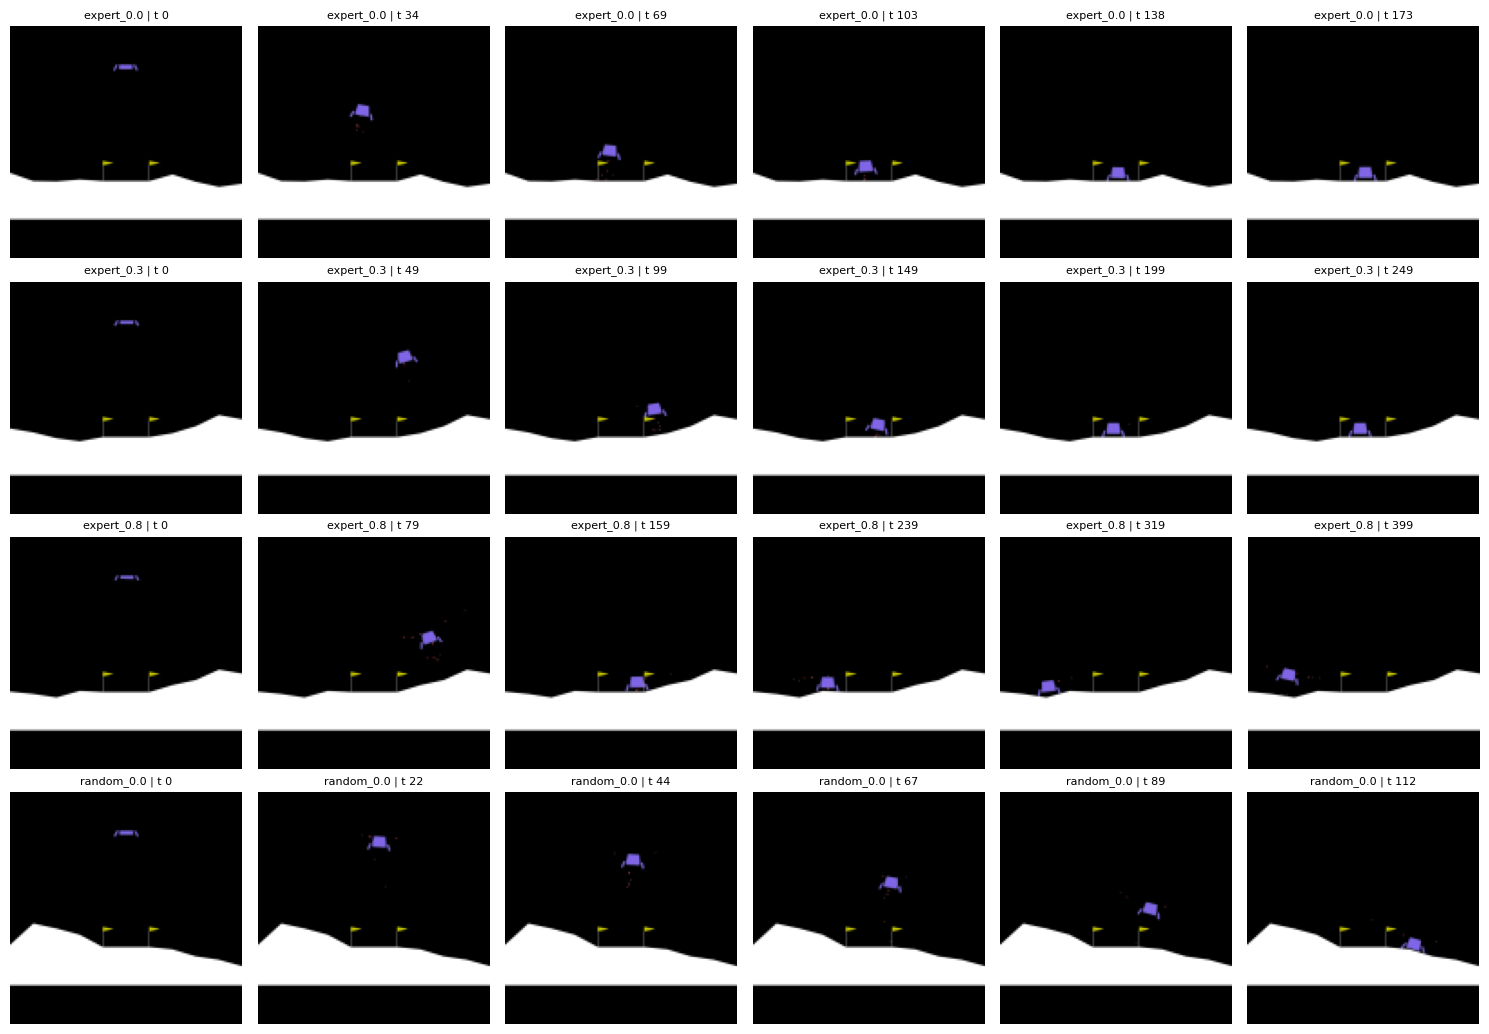

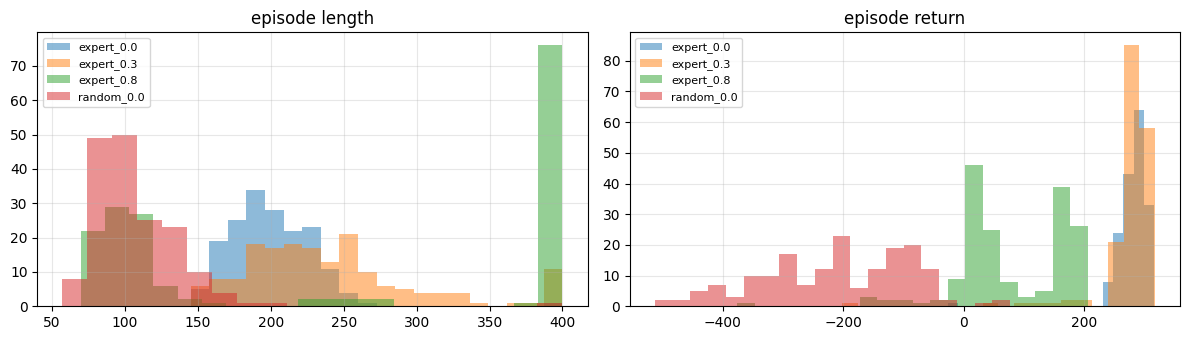

PosixPath('/Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/videos/data_review.mp4')

In [6]:
# Data - Review

policies = sorted(episode_df["policy"].unique())
fig, axes = plt.subplots(len(policies), 6, figsize=(15, 2.6 * len(policies)), squeeze=False)
for r, policy in enumerate(policies):
    i = int(episode_df[(episode_df["split"] == "train") & (episode_df["policy"] == policy)]["episode"].iloc[0])
    episode = datasets["train"][i]
    for c, t in enumerate(np.linspace(0, len(episode["frames"]) - 1, 6).astype(int)):
        axes[r, c].imshow(episode["frames"][t])
        axes[r, c].set_title(f"{policy} | t {t}", fontsize=8)
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for policy in policies:
    subset = episode_df[episode_df["policy"] == policy]
    axes[0].hist(subset["steps"], bins=20, alpha=0.5, label=policy)
    axes[1].hist(subset["return"], bins=20, alpha=0.5, label=policy)
axes[0].set_title("episode length")
axes[1].set_title("episode return")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

show_video(datasets["train"][0]["frames"][::2], "data_review.mp4", fps=25)

# JEPA

V-JEPA 2 (ViT-L/16) implemented from scratch, loaded with Meta's pretrained weights (`facebook/vjepa2-vitl-fpc64-256`). Steps 1–9 walk through one forward pass; steps 10–12 fine-tune the pretrained model on LunarLander with the JEPA objective (transfer learning, no pretraining).

## Setup

`JEPAConfig` holds the architecture. `VJEPA2_VITL` = V-JEPA 2 ViT-L/16; its weights come from the Meta checkpoint.

In [7]:
# JEPA - Setup

import copy
import gc
import json
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class JEPAConfig:
    crop_size: int = 256
    patch_size: int = 16
    tubelet_size: int = 2
    clip_frames: int = 16
    frame_stride: int = 2
    hidden: int = 1024
    depth: int = 24
    heads: int = 16
    pred_hidden: int = 384
    pred_depth: int = 12
    pred_heads: int = 12
    mlp_ratio: float = 4.0
    n_mask_tokens: int = 10

    @property
    def grid(self):
        return self.crop_size // self.patch_size

    @property
    def slots(self):
        return self.clip_frames // self.tubelet_size

    @property
    def n_tokens(self):
        return self.slots * self.grid * self.grid


VJEPA2_VITL = JEPAConfig()
CFG = VJEPA2_VITL

CROP_SIZE, PATCH_SIZE, TUBELET_SIZE = CFG.crop_size, CFG.patch_size, CFG.tubelet_size
CLIP_FRAMES, FRAME_STRIDE = CFG.clip_frames, CFG.frame_stride
GRID, T_SLOTS, N_TOKENS = CFG.grid, CFG.slots, CFG.n_tokens
HIDDEN, HEADS = CFG.hidden, CFG.heads
LN_EPS = 1e-6

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])


def init_weights(module, std=0.02):
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv3d)):
            nn.init.trunc_normal_(m.weight, std=std)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
    return module


torch.manual_seed(0)

CHECKPOINT_REPO = "facebook/vjepa2-vitl-fpc64-256"
_meta_checkpoint = None


def meta_checkpoint():
    global _meta_checkpoint
    if _meta_checkpoint is None:
        _meta_checkpoint = load_file(hf_hub_download(CHECKPOINT_REPO, "model.safetensors"))
    return _meta_checkpoint


def release_meta_checkpoint():
    global _meta_checkpoint
    _meta_checkpoint = None
    gc.collect()


def memory_gb():
    return torch.mps.driver_allocated_memory() / 1e9 if DEVICE.type == "mps" else 0.0

ENCODER_RULES = [("embeddings.patch_embeddings.", "tubelet."), ("layer.", "blocks."), ("layernorm.", "norm.")]
PREDICTOR_RULES = [
    ("embeddings.predictor_embeddings.", "embed."),
    ("embeddings.mask_tokens", "mask_tokens"),
    ("layer.", "blocks."),
    ("layernorm.", "norm."),
]


def weights(prefix, rules=()):
    state = {k[len(prefix):]: v for k, v in meta_checkpoint().items() if k.startswith(prefix)}
    for old, new in rules:
        state = {k.replace(old, new): v for k, v in state.items()}
    return state

JEPA_EPISODE = datasets["train"][0]

print("device:", DEVICE)
print("config:", CFG)
print("checkpoint tensors:", len(meta_checkpoint()))
print("tokens per clip:", N_TOKENS, f"= {T_SLOTS} slots x {GRID}x{GRID}")
print("episode:", JEPA_EPISODE["policy"], "| frames", JEPA_EPISODE["frames"].shape)

/Users/adriankazi/miniconda3/envs/dl-video-learning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps
config: JEPAConfig(crop_size=256, patch_size=16, tubelet_size=2, clip_frames=16, frame_stride=2, hidden=1024, depth=24, heads=16, pred_hidden=384, pred_depth=12, pred_heads=12, mlp_ratio=4.0, n_mask_tokens=10)
checkpoint tensors: 587
tokens per clip: 2048 = 8 slots x 16x16
episode: expert_0.0 | frames (174, 128, 128, 3)


## 1. Clip

16 frames (stride 2) → pad to square → 256×256 → ImageNet normalization. No center crop, so the whole scene stays in view.

In [8]:
# JEPA - Clip

def make_clip(frames, n_frames=CLIP_FRAMES, stride=FRAME_STRIDE, start=0, crop_size=CROP_SIZE):
    frames = frames[start:start + n_frames * stride:stride]
    h, w = frames.shape[1:3]
    side = max(h, w)

    padded = np.zeros((len(frames), side, side, 3), dtype=np.uint8)
    top, left = (side - h) // 2, (side - w) // 2
    padded[:, top:top + h, left:left + w] = frames

    x = torch.from_numpy(padded).float().div(255).permute(0, 3, 1, 2)
    x = F.interpolate(x, size=(crop_size, crop_size), mode="bilinear", antialias=True)
    x = (x - IMAGENET_MEAN[:, None, None]) / IMAGENET_STD[:, None, None]

    return x.unsqueeze(0)  # [B, T, C, H, W]


def clip_to_images(clip):
    x = clip[0].cpu() * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    return x.clamp(0, 1).permute(0, 2, 3, 1).numpy()


def plot_slots(overlays=None, title="", cmap="magma", alpha=0.6, grid_lines=False):
    fig, axes = plt.subplots(1, T_SLOTS, figsize=(2.2 * T_SLOTS, 2.6))
    vmin = vmax = None
    if overlays is not None and np.asarray(overlays).ndim == 3:
        vmin, vmax = float(np.nanmin(overlays)), float(np.nanmax(overlays))

    for t, ax in enumerate(axes):
        ax.imshow(slot_images[t])
        if overlays is not None:
            ax.imshow(
                overlays[t],
                extent=(0, CROP_SIZE, CROP_SIZE, 0),
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha,
                interpolation="nearest",
            )
        if grid_lines:
            for p in range(0, CROP_SIZE + 1, PATCH_SIZE):
                ax.axhline(p, color="white", linewidth=0.3, alpha=0.6)
                ax.axvline(p, color="white", linewidth=0.3, alpha=0.6)
        ax.set_title(f"slot {t} | f{t * TUBELET_SIZE}-{t * TUBELET_SIZE + 1}", fontsize=8)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

raw frames: (174, 128, 128, 3)
clip: (1, 16, 3, 256, 256) [B, T, C, H, W]


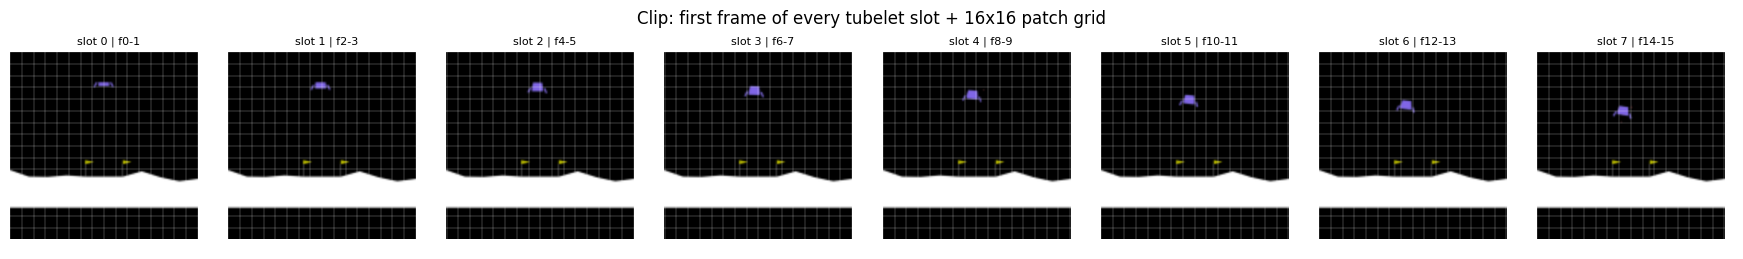

In [9]:
# JEPA - Clip - Apply + Visualize

jepa_frames = JEPA_EPISODE["frames"]
clip = make_clip(jepa_frames).to(DEVICE)
slot_images = clip_to_images(clip)[::TUBELET_SIZE]

print("raw frames:", jepa_frames.shape)
print("clip:", tuple(clip.shape), "[B, T, C, H, W]")

plot_slots(title="Clip: first frame of every tubelet slot + 16x16 patch grid", grid_lines=True)

## 2. Tubelet Embedding

Conv3d with kernel = stride = 2×16×16: every tubelet (2 frames × 16×16 px) becomes one token.

In [10]:
# JEPA - Tubelet Embedding

class TubeletEmbedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        size = (cfg.tubelet_size, cfg.patch_size, cfg.patch_size)
        self.proj = nn.Conv3d(3, cfg.hidden, kernel_size=size, stride=size)

    def forward(self, clip):
        x = self.proj(clip.permute(0, 2, 1, 3, 4))  # [B, D, T/2, grid, grid]
        return x.flatten(2).transpose(1, 2)          # [B, N, D]


def pca_rgb(tokens, basis=None):
    x = tokens.detach().float().cpu().reshape(-1, tokens.shape[-1])

    if basis is None:
        mean = x.mean(0)
        _, _, V = torch.pca_lowrank(x - mean, q=3, center=False)
        proj = (x - mean) @ V
        basis = (mean, V, proj.quantile(0.01, dim=0), proj.quantile(0.99, dim=0))

    mean, V, lo, hi = basis
    rgb = (((x - mean) @ V - lo) / (hi - lo)).clamp(0, 1)
    return rgb.numpy(), basis  # [n, 3]


tubelet = TubeletEmbedding(CFG).to(DEVICE)
tubelet.load_state_dict(weights("encoder.embeddings.patch_embeddings."))

<All keys matched successfully>

tubelet tokens: (1, 2048, 1024) [B, N, D]


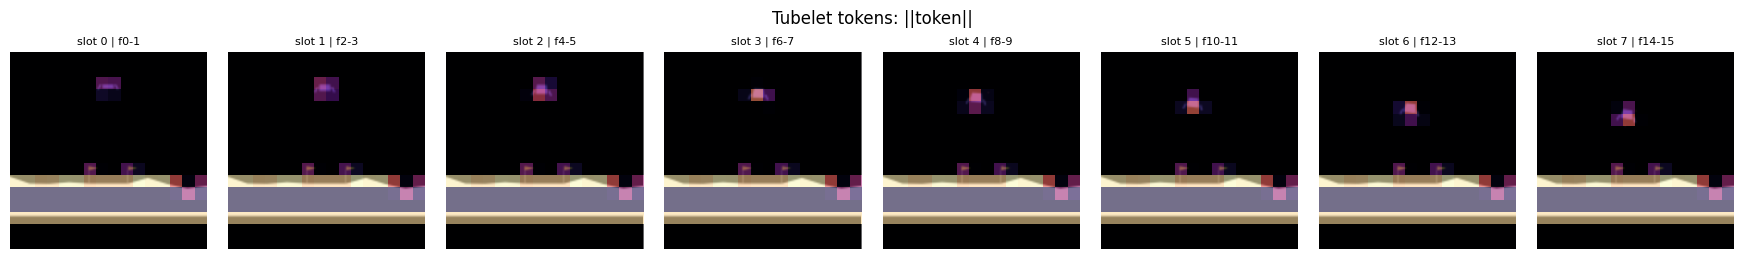

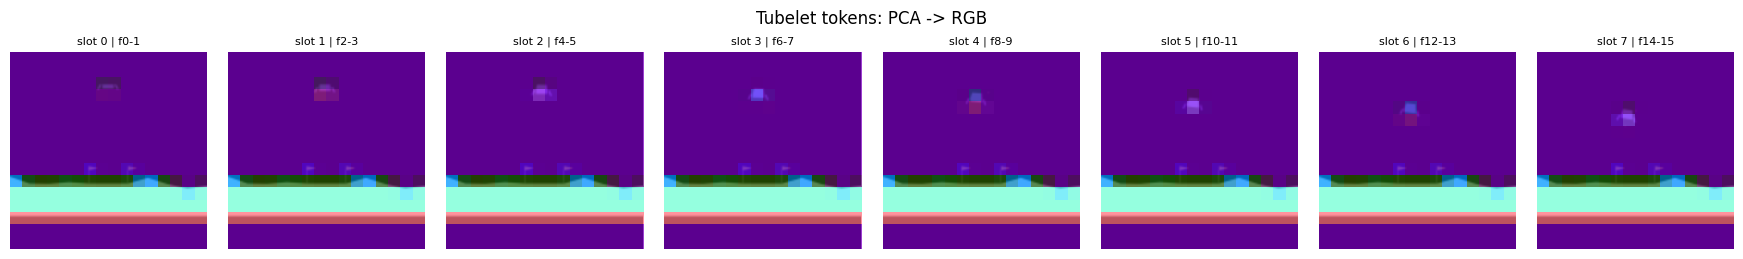

In [11]:
# JEPA - Tubelet Embedding - Apply + Visualize

with torch.no_grad():
    tubelet_tokens = tubelet(clip)

print("tubelet tokens:", tuple(tubelet_tokens.shape), "[B, N, D]")

token_norm = tubelet_tokens[0].norm(dim=-1).view(T_SLOTS, GRID, GRID).cpu().numpy()
plot_slots(token_norm, title="Tubelet tokens: ||token||")

tubelet_rgb, _ = pca_rgb(tubelet_tokens[0])
plot_slots(tubelet_rgb.reshape(T_SLOTS, GRID, GRID, 3), title="Tubelet tokens: PCA -> RGB", alpha=0.75)

## 3. 3D RoPE

No position embeddings are added. Instead q/k are rotated: head dims are split into 3 groups rotated by angles proportional to the time / height / width index of the token.

In [12]:
# JEPA - 3D RoPE

def token_positions(ids, grid):
    tokens_per_slot = grid * grid
    t = ids // tokens_per_slot
    h = (ids % tokens_per_slot) // grid
    w = ids % grid
    return t, h, w


def rotate(x, pos):
    d = x.shape[-1]
    omega = 1.0 / 10000 ** (torch.arange(d // 2, device=x.device, dtype=x.dtype) / (d / 2))
    angle = pos[:, None, :, None].to(x.dtype) * omega      # [B, 1, N, d/2]
    sin = torch.cat([angle.sin(), angle.sin()], dim=-1)
    cos = torch.cat([angle.cos(), angle.cos()], dim=-1)

    x1, x2 = x.unflatten(-1, (-1, 2)).unbind(-1)
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x * cos + x_rot * sin


def apply_rope(x, ids, grid):
    # x: [B, heads, N, head_dim], ids: [B, N]
    d = 2 * ((x.shape[-1] // 3) // 2)
    parts, s = [], 0
    for pos in token_positions(ids, grid):
        parts.append(rotate(x[..., s:s + d], pos))
        s += d
    parts.append(x[..., s:])
    return torch.cat(parts, dim=-1)

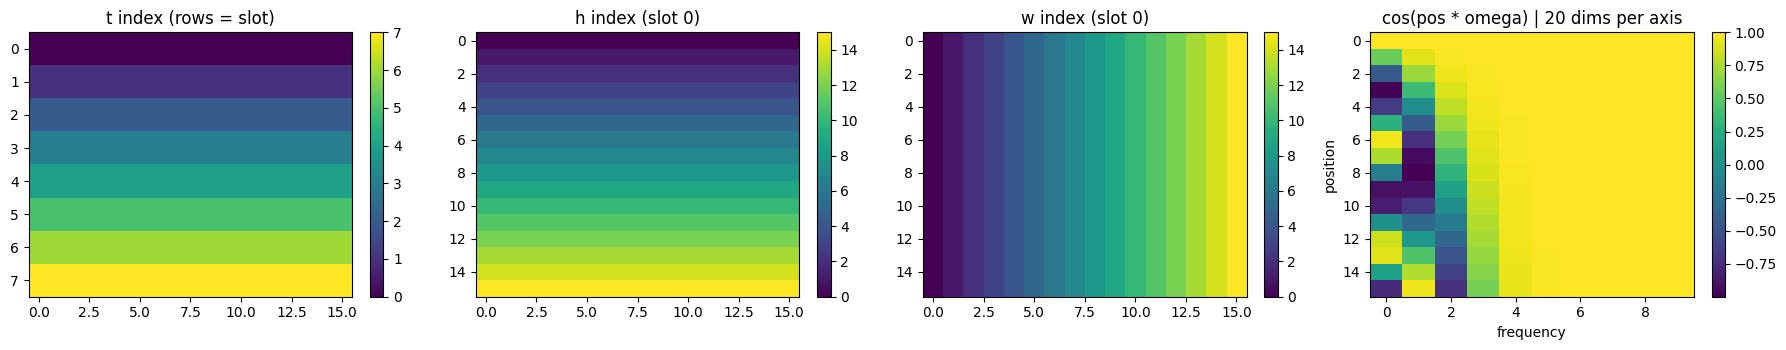

head dim: 64 | rotated per axis: 20 | unrotated: 4


In [13]:
# JEPA - 3D RoPE - Apply + Visualize

all_ids = torch.arange(N_TOKENS, device=DEVICE)[None]
center = 4 * GRID * GRID + 8 * GRID + 8  # slot 4, h 8, w 8

t_ids, h_ids, w_ids = [p[0].view(T_SLOTS, GRID, GRID).cpu().numpy() for p in token_positions(all_ids, GRID)]

rope_dim = 2 * (((HIDDEN // HEADS) // 3) // 2)
omega = 1.0 / 10000 ** (np.arange(rope_dim // 2) / (rope_dim / 2))
angle_cos = np.cos(np.arange(GRID)[:, None] * omega[None])

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, grid, title in [
    (axes[0], t_ids[:, 0, :], "t index (rows = slot)"),
    (axes[1], h_ids[0], "h index (slot 0)"),
    (axes[2], w_ids[0], "w index (slot 0)"),
    (axes[3], angle_cos, f"cos(pos * omega) | {rope_dim} dims per axis"),
]:
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[3].set_xlabel("frequency")
axes[3].set_ylabel("position")

plt.tight_layout()
plt.show()

print("head dim:", HIDDEN // HEADS, "| rotated per axis:", rope_dim, "| unrotated:", HIDDEN // HEADS - 3 * rope_dim)

## 4. Attention

q, k, v projections → RoPE on q and k → softmax(qkᵀ/√d)·v → output projection.

In [14]:
# JEPA - Attention

class Attention(nn.Module):
    def __init__(self, dim, heads, grid):
        super().__init__()
        self.heads = heads
        self.head_dim = dim // heads
        self.grid = grid
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, ids, return_attention=False):
        B, N, _ = x.shape
        q, k, v = [
            layer(x).view(B, N, self.heads, self.head_dim).transpose(1, 2)
            for layer in (self.query, self.key, self.value)
        ]
        q, k = apply_rope(q, ids, self.grid), apply_rope(k, ids, self.grid)

        attention = None
        if return_attention:
            attention = (q @ k.transpose(-2, -1) * self.head_dim ** -0.5).softmax(dim=-1)
            out = attention @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v)

        out = out.transpose(1, 2).reshape(B, N, -1)
        return self.proj(out), attention

attention out: (1, 2048, 1024)
attention map: (1, 16, 2048, 2048) [B, heads, N, N]


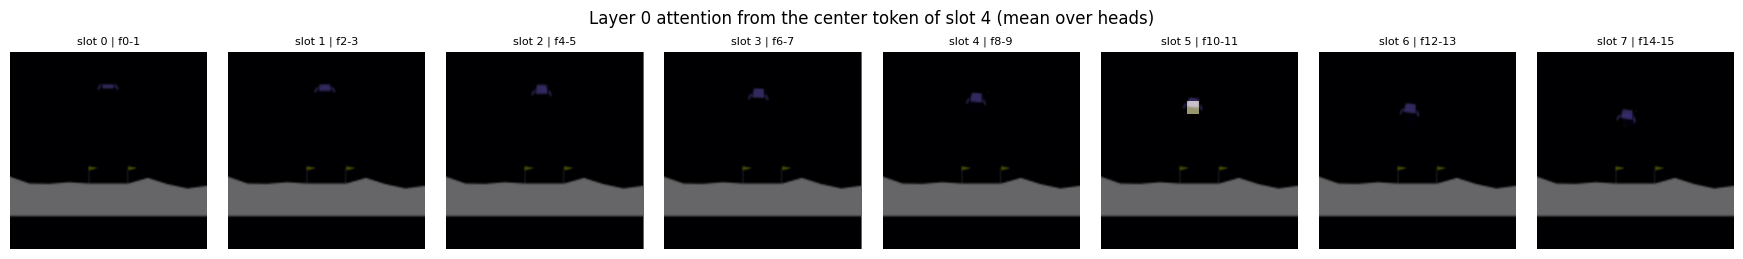

In [15]:
# JEPA - Attention - Apply + Visualize (layer 0)

norm_0 = nn.LayerNorm(HIDDEN, eps=LN_EPS).to(DEVICE)
norm_0.load_state_dict(weights("encoder.layer.0.norm1."))
attention_0 = Attention(HIDDEN, HEADS, GRID).to(DEVICE)
attention_0.load_state_dict(weights("encoder.layer.0.attention."))

with torch.no_grad():
    attention_out, attention_0_map = attention_0(norm_0(tubelet_tokens), all_ids, return_attention=True)

print("attention out:", tuple(attention_out.shape))
print("attention map:", tuple(attention_0_map.shape), "[B, heads, N, N]")

query_map = attention_0_map[0, :, center].mean(0).view(T_SLOTS, GRID, GRID).cpu().numpy()
plot_slots(query_map, title="Layer 0 attention from the center token of slot 4 (mean over heads)")

## 5. Transformer Block

Pre-norm: x + Attention(LN(x)), then x + MLP(LN(x)) with GELU, dim → 4·dim → dim.

In [16]:
# JEPA - Transformer Block

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, int(dim * mlp_ratio))
        self.fc2 = nn.Linear(int(dim * mlp_ratio), dim)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class Block(nn.Module):
    def __init__(self, dim, heads, grid, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, eps=LN_EPS)
        self.attention = Attention(dim, heads, grid)
        self.norm2 = nn.LayerNorm(dim, eps=LN_EPS)
        self.mlp = MLP(dim, mlp_ratio)

    def forward(self, x, ids, return_attention=False):
        attention_out, attention = self.attention(self.norm1(x), ids, return_attention)
        x = x + attention_out
        x = x + self.mlp(self.norm2(x))
        return x, attention

block 0 out: (1, 2048, 1024)


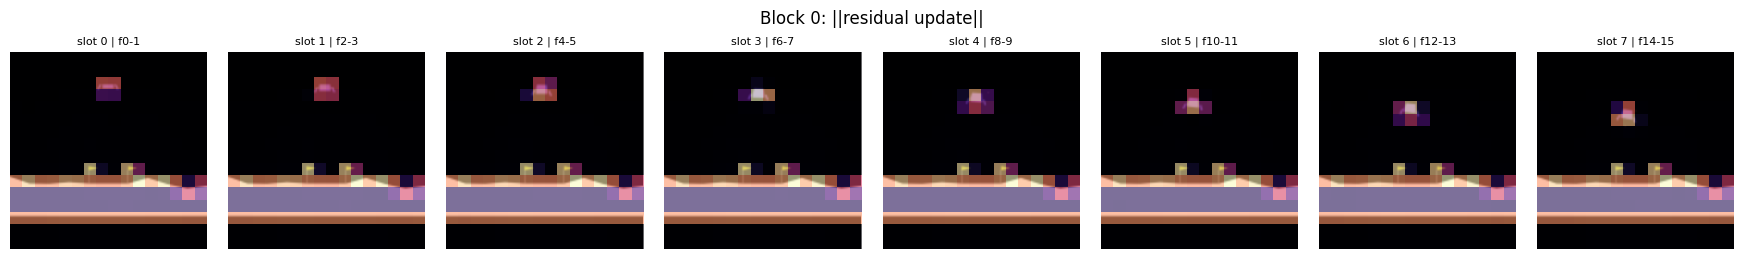

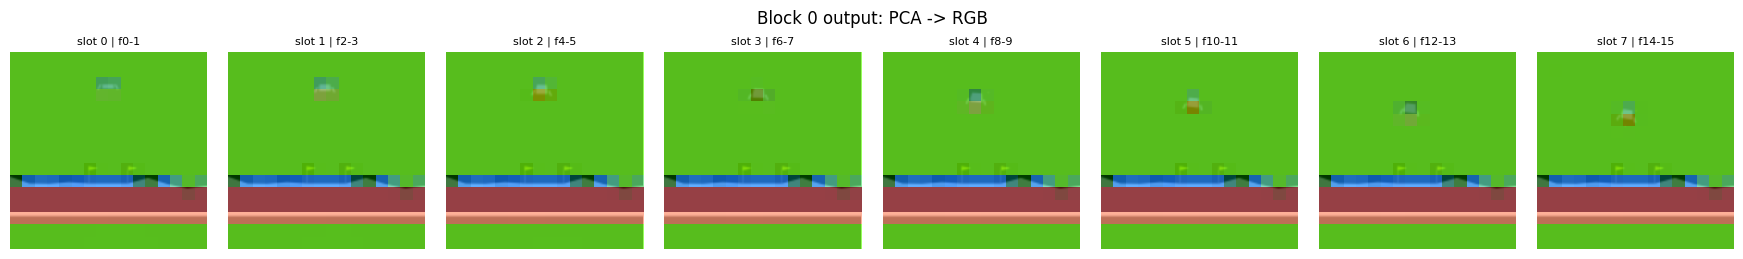

In [17]:
# JEPA - Transformer Block - Apply + Visualize (block 0)

block_0 = Block(HIDDEN, HEADS, GRID).to(DEVICE)
block_0.load_state_dict(weights("encoder.layer.0."))

with torch.no_grad():
    block_0_tokens, _ = block_0(tubelet_tokens, all_ids)

update = (block_0_tokens - tubelet_tokens)[0].norm(dim=-1).view(T_SLOTS, GRID, GRID).cpu().numpy()
print("block 0 out:", tuple(block_0_tokens.shape))

plot_slots(update, title="Block 0: ||residual update||")
plot_slots(pca_rgb(block_0_tokens[0])[0].reshape(T_SLOTS, GRID, GRID, 3), title="Block 0 output: PCA -> RGB", alpha=0.75)

## 6. Encoder

Tubelet embedding → `depth` blocks → LayerNorm. With `ids` it encodes only those tokens (the context encoder in step 8).

In [18]:
# JEPA - Encoder

class Encoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tubelet = TubeletEmbedding(cfg)
        self.blocks = nn.ModuleList([Block(cfg.hidden, cfg.heads, cfg.grid, cfg.mlp_ratio) for _ in range(cfg.depth)])
        self.norm = nn.LayerNorm(cfg.hidden, eps=LN_EPS)

    def forward(self, clip, ids=None):
        x = self.tubelet(clip)
        B, N, D = x.shape

        if ids is None:
            ids = torch.arange(N, device=x.device)[None].expand(B, -1)
        else:
            x = x.gather(1, ids[..., None].expand(-1, -1, D))

        for block in self.blocks:
            x, _ = block(x, ids)

        return self.norm(x)


encoder = Encoder(CFG).to(DEVICE).eval()
encoder.load_state_dict(weights("encoder.", ENCODER_RULES))

print("encoder params:", f"{sum(p.numel() for p in encoder.parameters()) / 1e6:.1f}M")

encoder params: 303.9M


features: (1, 2048, 1024) [B, N, D]


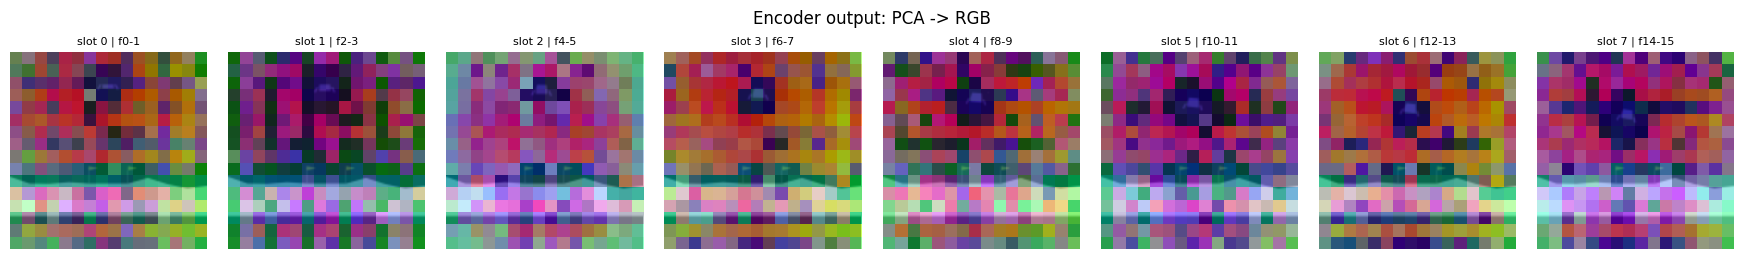

In [19]:
# JEPA - Encoder - Apply + Visualize

with torch.no_grad():
    features = encoder(clip)

print("features:", tuple(features.shape), "[B, N, D]")

features_rgb, features_basis = pca_rgb(features[0])
plot_slots(features_rgb.reshape(T_SLOTS, GRID, GRID, 3), title="Encoder output: PCA -> RGB", alpha=0.75)

## 7. Masking

Multi-block 3D masks: spatial blocks repeated over every time slot. Short-range = 8 blocks × 15% area, long-range = 2 blocks × 70% area. Masked tokens = targets, the rest = context.

In [20]:
# JEPA - Masking

MASK_CONFIGS = [
    {"name": "short-range", "n_blocks": 8, "scale": 0.15},
    {"name": "long-range", "n_blocks": 2, "scale": 0.70},
]


def sample_spatial_mask(n_blocks, scale, grid, aspect_ratio=(0.75, 1.5), generator=None):
    mask = torch.zeros(grid, grid, dtype=torch.bool)

    for _ in range(n_blocks):
        log_ar = torch.empty(1).uniform_(np.log(aspect_ratio[0]), np.log(aspect_ratio[1]), generator=generator)
        ar = float(log_ar.exp())
        area = scale * grid * grid
        h = int(np.clip(round(np.sqrt(area * ar)), 1, grid))
        w = int(np.clip(round(np.sqrt(area / ar)), 1, grid))
        top = int(torch.randint(0, grid - h + 1, (1,), generator=generator))
        left = int(torch.randint(0, grid - w + 1, (1,), generator=generator))
        mask[top:top + h, left:left + w] = True

    return mask


def mask_to_ids(spatial_mask, slots):
    target = spatial_mask[None].expand(slots, -1, -1).flatten()
    context_ids = (~target).nonzero().flatten()[None].to(DEVICE)
    target_ids = target.nonzero().flatten()[None].to(DEVICE)
    return context_ids, target_ids


def sample_masks(cfg, generator=None, min_context=0.1):
    # resample until the context keeps at least `min_context` of the spatial positions (V-JEPA `min_keep`)
    min_keep = max(1, int(min_context * cfg.grid * cfg.grid))
    masks = []
    for config in MASK_CONFIGS:
        while True:
            spatial_mask = sample_spatial_mask(config["n_blocks"], config["scale"], cfg.grid, generator=generator)
            if int((~spatial_mask).sum()) >= min_keep:
                break
        masks.append((config["name"], *mask_to_ids(spatial_mask, cfg.slots)))
    return masks

short-range | context  528 | target 1520
 long-range | context  296 | target 1752


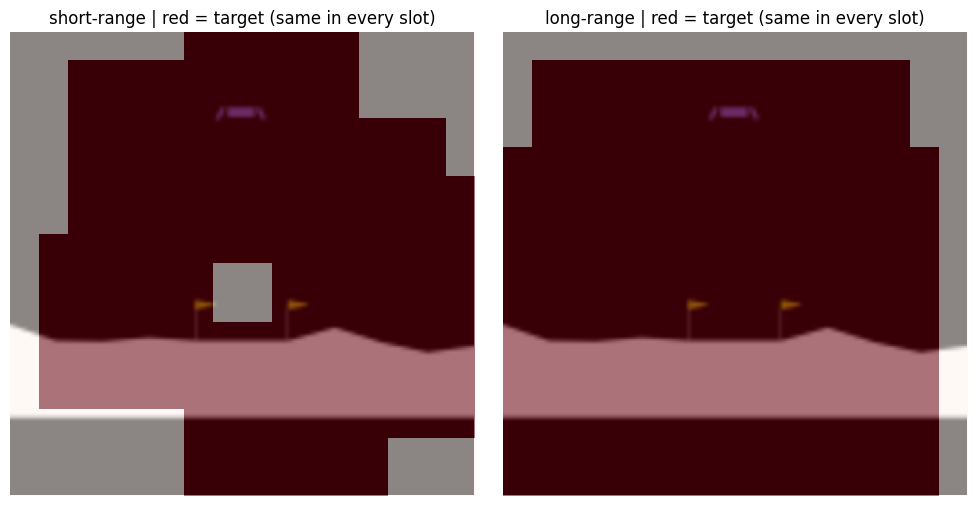

In [21]:
# JEPA - Masking - Apply + Visualize

mask_generator = torch.Generator().manual_seed(0)

masks = []
for config in MASK_CONFIGS:
    spatial_mask = sample_spatial_mask(config["n_blocks"], config["scale"], GRID, generator=mask_generator)
    context_ids, target_ids = mask_to_ids(spatial_mask, T_SLOTS)
    masks.append({**config, "spatial": spatial_mask, "context_ids": context_ids, "target_ids": target_ids})
    print(f"{config['name']:>11} | context {context_ids.shape[1]:4d} | target {target_ids.shape[1]:4d}")

fig, axes = plt.subplots(1, len(masks), figsize=(5 * len(masks), 5))
for ax, mask in zip(axes, masks):
    ax.imshow(slot_images[0])
    ax.imshow(
        mask["spatial"].numpy(),
        extent=(0, CROP_SIZE, CROP_SIZE, 0),
        cmap="Reds",
        alpha=0.55,
        interpolation="nearest",
    )
    ax.set_title(f"{mask['name']} | red = target (same in every slot)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Predictor

The context encoder sees only context tokens. The predictor (narrower transformer) gets the projected context + one learned mask token per target position (RoPE tells it where), and predicts the target features. Target = LayerNorm (no affine) of the full-clip target-encoder output. The checkpoint only trains mask token 0 (tokens 1–9 are identical), so every mask uses token 0.

In [22]:
# JEPA - Predictor

class Predictor(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embed = nn.Linear(cfg.hidden, cfg.pred_hidden)
        self.mask_tokens = nn.Parameter(torch.zeros(cfg.n_mask_tokens, 1, 1, cfg.pred_hidden))
        self.blocks = nn.ModuleList(
            [Block(cfg.pred_hidden, cfg.pred_heads, cfg.grid, cfg.mlp_ratio) for _ in range(cfg.pred_depth)]
        )
        self.norm = nn.LayerNorm(cfg.pred_hidden, eps=LN_EPS)
        self.proj = nn.Linear(cfg.pred_hidden, cfg.hidden)

    def forward(self, context, context_ids, target_ids, mask_index=0):
        B, n_context, _ = context.shape
        targets = self.mask_tokens[mask_index].expand(B, target_ids.shape[1], -1)

        x = torch.cat([self.embed(context), targets], dim=1)
        ids = torch.cat([context_ids, target_ids], dim=1)

        for block in self.blocks:
            x, _ = block(x, ids)

        return self.proj(self.norm(x[:, n_context:]))


def gather_tokens(x, ids):
    return x.gather(1, ids[..., None].expand(-1, -1, x.shape[-1]))


def scatter_to_grid(values, ids, fill):
    grid = np.tile(np.asarray(fill, dtype=np.float32), (N_TOKENS, 1))
    grid[ids[0].cpu().numpy()] = values
    grid = grid.reshape(T_SLOTS, GRID, GRID, -1)
    return grid[..., 0] if grid.shape[-1] == 1 else grid


predictor = Predictor(CFG).to(DEVICE).eval()
predictor.load_state_dict(weights("predictor.", PREDICTOR_RULES))

print("predictor params:", f"{sum(p.numel() for p in predictor.parameters()) / 1e6:.1f}M")

predictor params: 22.1M


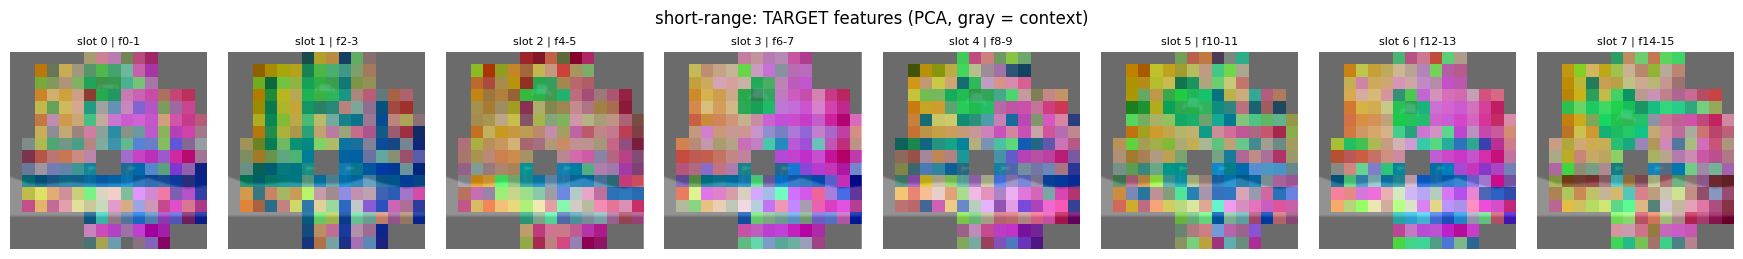

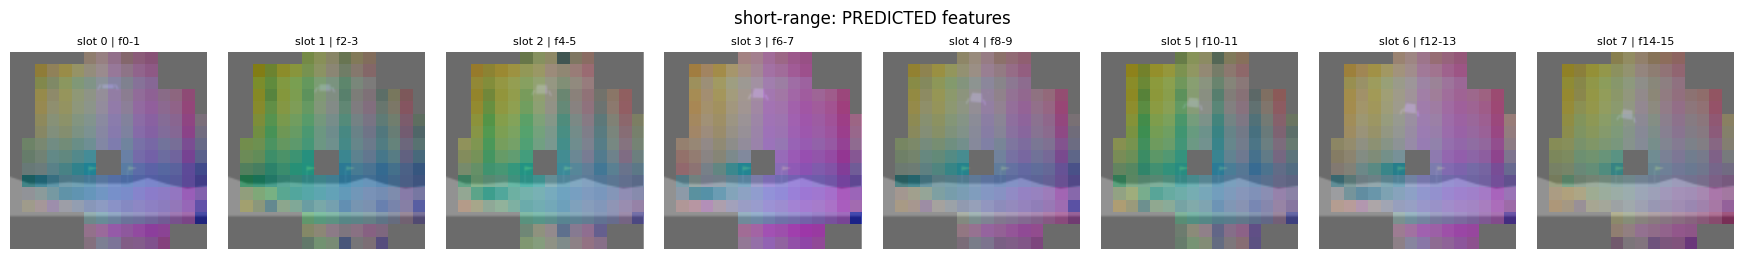

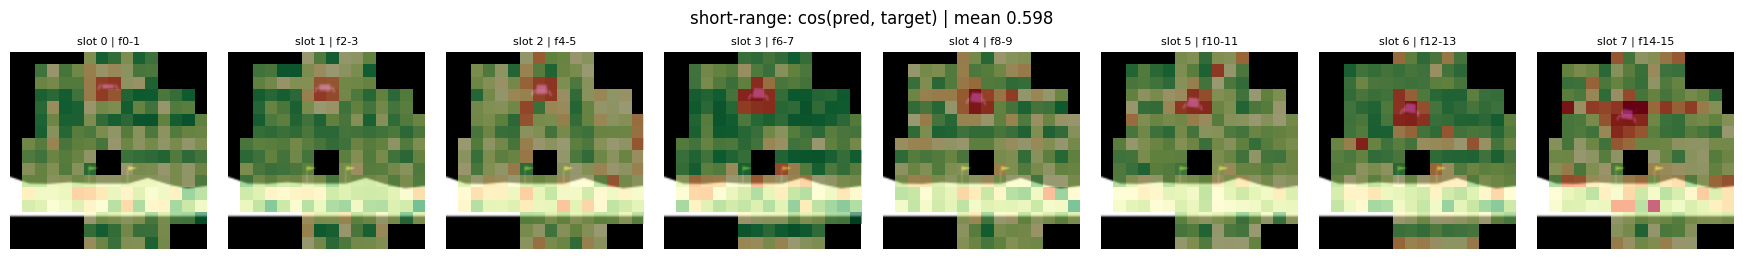

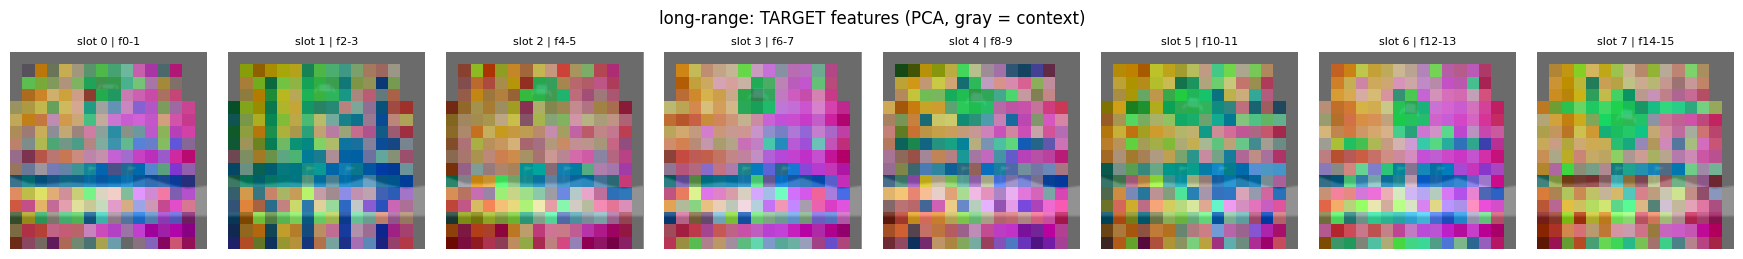

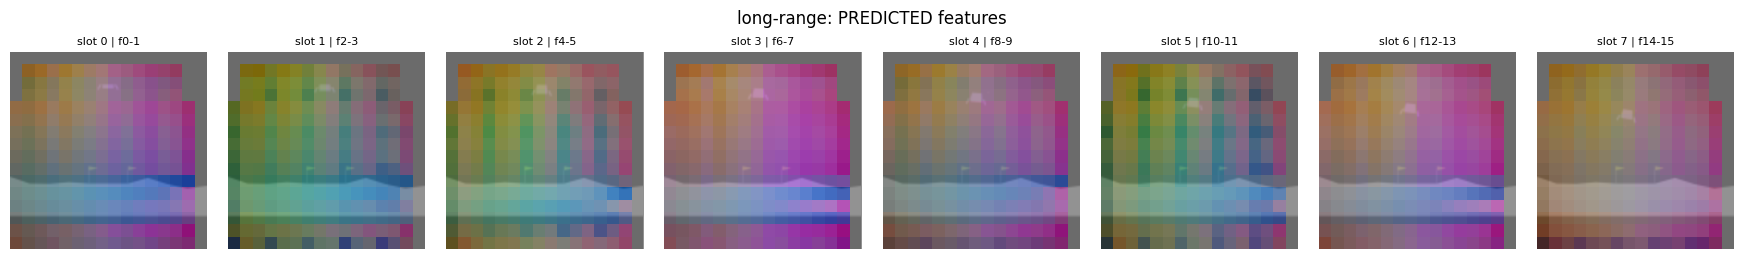

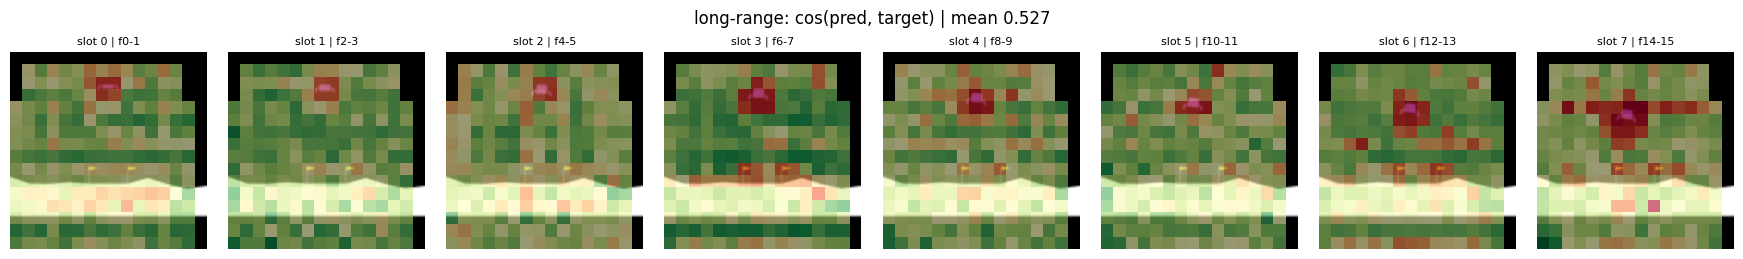

In [23]:
# JEPA - Predictor - Apply + Visualize

target_features = F.layer_norm(features, (HIDDEN,))
_, target_basis = pca_rgb(target_features[0])

with torch.no_grad():
    for mask in masks:
        mask["context"] = encoder(clip, ids=mask["context_ids"])
        mask["target"] = gather_tokens(target_features, mask["target_ids"])
        mask["prediction"] = predictor(mask["context"], mask["context_ids"], mask["target_ids"])

for mask in masks:
    target_rgb, _ = pca_rgb(mask["target"][0], target_basis)
    prediction_rgb, _ = pca_rgb(mask["prediction"][0], target_basis)
    cosine = F.cosine_similarity(mask["prediction"][0], mask["target"][0], dim=-1).cpu().numpy()

    gray = [0.5, 0.5, 0.5]
    plot_slots(scatter_to_grid(target_rgb, mask["target_ids"], gray),
               title=f"{mask['name']}: TARGET features (PCA, gray = context)", alpha=0.85)
    plot_slots(scatter_to_grid(prediction_rgb, mask["target_ids"], gray),
               title=f"{mask['name']}: PREDICTED features", alpha=0.85)
    plot_slots(scatter_to_grid(cosine[:, None], mask["target_ids"], [np.nan]),
               title=f"{mask['name']}: cos(pred, target) | mean {cosine.mean():.3f}", cmap="RdYlGn")

## 9. Loss

L1 between predicted and target features, averaged over targets and over both masks.

In [24]:
# JEPA - Loss

def jepa_loss(prediction, target):
    return (prediction - target).abs().mean()

short-range | L1 0.5558


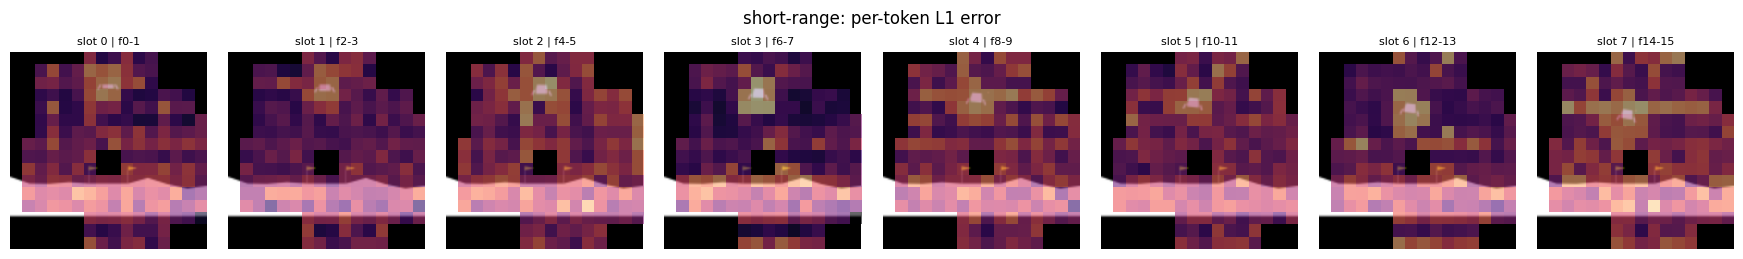

 long-range | L1 0.5934


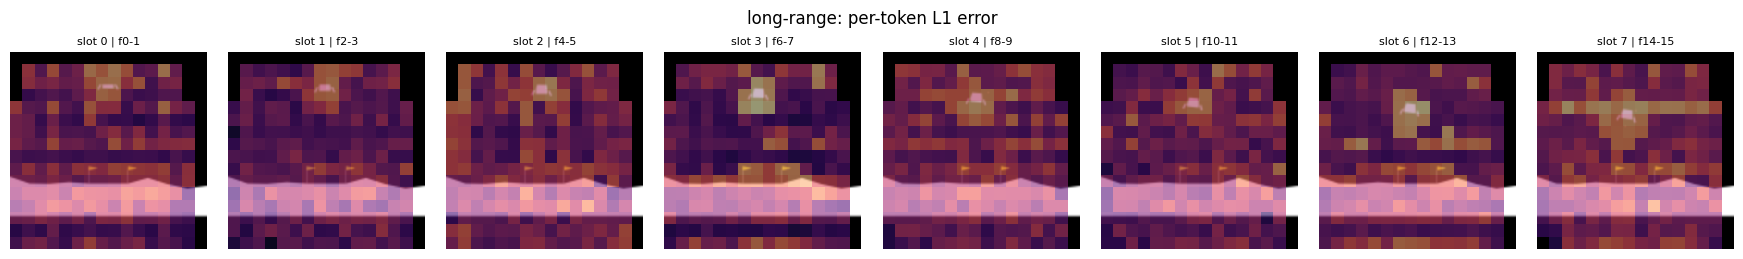

total loss: 0.5745704174041748


In [25]:
# JEPA - Loss - Apply + Visualize

for mask in masks:
    loss = jepa_loss(mask["prediction"], mask["target"])
    print(f"{mask['name']:>11} | L1 {float(loss):.4f}")

    error = (mask["prediction"] - mask["target"])[0].abs().mean(-1).cpu().numpy()
    plot_slots(scatter_to_grid(error[:, None], mask["target_ids"], [np.nan]),
               title=f"{mask['name']}: per-token L1 error", cmap="magma")

print("total loss:", float(sum(jepa_loss(m["prediction"], m["target"]) for m in masks) / len(masks)))

## 10. Storage

Per run: `train.csv` (every step), `eval.csv` (every eval), `config.json`, `checkpoint.pt`.

In [26]:
# JEPA - Storage

STORAGE_DIR = ARTIFACTS_DIR / "storage"


class RunStorage:
    def __init__(self, name, config=None):
        self.name = name
        self.dir = STORAGE_DIR / name
        self.dir.mkdir(parents=True, exist_ok=True)
        self.config = config or {}
        self.train_rows = []
        self.eval_rows = []

    def log(self, **values):
        self.train_rows.append(values)

    def log_eval(self, **values):
        self.eval_rows.append(values)

    def save(self):
        pd.DataFrame(self.train_rows).to_csv(self.dir / "train.csv", index=False)
        pd.DataFrame(self.eval_rows).to_csv(self.dir / "eval.csv", index=False)
        (self.dir / "config.json").write_text(json.dumps(self.config, indent=2, default=str))

    @staticmethod
    def load(name):
        run_dir = STORAGE_DIR / name
        return (
            pd.read_csv(run_dir / "train.csv"),
            pd.read_csv(run_dir / "eval.csv"),
            json.loads((run_dir / "config.json").read_text()),
        )

In [27]:
# JEPA - Storage - Apply

STORAGE_DIR.mkdir(parents=True, exist_ok=True)

print("storage dir:", STORAGE_DIR)
print("stored runs:", sorted(p.name for p in STORAGE_DIR.iterdir() if p.is_dir()))

storage dir: /Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/storage
stored runs: ['jepa_original', 'vjepa2_original_scratch', 'vjepa2_original_scratch_patch16_10k', 'vjepa2_transfer_finetune']


## 11. Fine-tuning

Transfer learning: start from Meta's pretrained V-JEPA 2 ViT-L encoder + predictor and continue the JEPA objective on LunarLander `train` episodes. Only the last `trainable_blocks` encoder blocks (+ final norm) and the predictor are trained; the target encoder is the EMA of the context encoder. New masks every step, AdamW with warmup + cosine lr, grad clipping. 128 px LunarLander frames are upsampled to the model's 256 px input. Val = fixed clips from the `val` episodes.

In [28]:
# JEPA - Fine-tuning

FINETUNE_CFG = JEPAConfig(clip_frames=8)  # ViT-L weights; 8 frames → 1024 tokens so fine-tuning fits in 32 GB

FINETUNE = {
    "run_name": "vjepa2_transfer_finetune",
    # a finished checkpoint with the same config is loaded instead of retraining
    "seed": 0,
    "trainable_blocks": 4,
    "steps": 0,  # 0 = no fine-tuning, evaluate Meta's weights as they are; 500 = fine-tune
    "batch_size": 2,
    "lr": 1e-4,
    "start_lr": 1e-6,
    "final_lr": 1e-6,
    "warmup_steps": 50,
    "weight_decay": 0.04,
    "final_weight_decay": 0.04,
    "ema_start": 0.999,
    "ema_end": 1.0,
    "grad_clip": 1.0,
    "crop_scale": (0.8, 1.0),
    "crop_aspect": (0.75, 1.35),
    "eval_every": 100,
    "log_every": 20,
}


# ---- data

def square_resize(frames, size):
    h, w = frames.shape[1:3]
    side = max(h, w)
    out = np.zeros((len(frames), size, size, 3), dtype=np.uint8)
    for i, frame in enumerate(frames):
        canvas = np.zeros((side, side, 3), dtype=np.uint8)
        canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = frame
        out[i] = cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)
    return out


def episode_videos(episodes, cfg):
    # frames stay at their stored resolution; to_input resizes to cfg.crop_size
    span = (cfg.clip_frames - 1) * cfg.frame_stride + 1
    return [ep["frames"] for ep in episodes if len(ep["frames"]) >= span]


def sample_clip(video, cfg, rng, start=None):
    span = (cfg.clip_frames - 1) * cfg.frame_stride + 1
    if start is None:
        start = int(rng.integers(0, len(video) - span + 1))
    return video[start:start + span:cfg.frame_stride]  # [T, S, S, 3] uint8


def to_input(clips, cfg, rng=None, crop_scale=(0.3, 1.0), crop_aspect=(0.75, 1.35)):
    x = torch.from_numpy(np.stack(clips)).to(DEVICE).float().div(255).permute(0, 1, 4, 2, 3)  # [B, T, C, s, s]
    S, s = cfg.crop_size, x.shape[-1]
    crops = []
    for clip_x in x:
        if rng is not None:
            area = rng.uniform(*crop_scale) * s * s
            ar = np.exp(rng.uniform(np.log(crop_aspect[0]), np.log(crop_aspect[1])))
            h = int(np.clip(round(np.sqrt(area / ar)), 8, s))
            w = int(np.clip(round(np.sqrt(area * ar)), 8, s))
            top, left = int(rng.integers(0, s - h + 1)), int(rng.integers(0, s - w + 1))
            clip_x = clip_x[:, :, top:top + h, left:left + w]
        crops.append(F.interpolate(clip_x, size=(S, S), mode="bilinear", antialias=True) if clip_x.shape[-1] != S or clip_x.shape[-2] != S else clip_x)
    x = torch.stack(crops)
    mean, std = IMAGENET_MEAN.to(DEVICE)[:, None, None], IMAGENET_STD.to(DEVICE)[:, None, None]
    return (x - mean) / std


# ---- models + optimizer

def trainable_prefixes(cfg, config):
    first = cfg.depth - config["trainable_blocks"]
    return tuple(f"blocks.{i}." for i in range(first, cfg.depth)) + ("norm.",)


def build_finetune_models(cfg, seed):
    torch.manual_seed(seed)
    context_encoder = Encoder(cfg).to(DEVICE)
    context_encoder.load_state_dict(weights("encoder.", ENCODER_RULES))
    jepa_predictor = Predictor(cfg).to(DEVICE)
    jepa_predictor.load_state_dict(weights("predictor.", PREDICTOR_RULES))

    prefixes = trainable_prefixes(cfg, FINETUNE)
    for name, p in context_encoder.named_parameters():
        p.requires_grad_(name.startswith(prefixes))

    context_encoder.train()
    jepa_predictor.train()
    target_encoder = copy.deepcopy(context_encoder).requires_grad_(False).eval()
    return context_encoder, jepa_predictor, target_encoder


def trainable_state(module, cfg):
    prefixes = trainable_prefixes(cfg, FINETUNE)
    return {k: v for k, v in module.state_dict().items() if k.startswith(prefixes)}


def build_optimizer(modules, lr, weight_decay):
    decay, no_decay = [], []
    for module in modules:
        for p in module.parameters():
            if p.requires_grad:
                (no_decay if p.ndim < 2 else decay).append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}], lr=lr
    )


def schedules(step, config):
    total, warmup = config["steps"], config["warmup_steps"]
    if step < warmup:
        lr = config["start_lr"] + (config["lr"] - config["start_lr"]) * step / warmup
    else:
        progress = (step - warmup) / max(1, total - warmup)
        lr = config["final_lr"] + (config["lr"] - config["final_lr"]) * 0.5 * (1 + np.cos(np.pi * progress))
    wd = config["weight_decay"] + (config["final_weight_decay"] - config["weight_decay"]) * 0.5 * (1 - np.cos(np.pi * step / total))
    momentum = config["ema_start"] + (config["ema_end"] - config["ema_start"]) * step / total
    return lr, wd, momentum


@torch.no_grad()
def ema_update(target_encoder, context_encoder, momentum):
    for target_param, param in zip(target_encoder.parameters(), context_encoder.parameters()):
        target_param.mul_(momentum).add_(param.detach(), alpha=1 - momentum)


def module_grad_norm(module):
    grads = [p.grad.detach().norm() for p in module.parameters() if p.grad is not None]
    return float(torch.stack(grads).norm()) if grads else 0.0


def module_param_norm(module):
    return float(torch.stack([p.detach().norm() for p in module.parameters()]).norm())


def effective_rank(tokens):
    x = tokens.reshape(-1, tokens.shape[-1]).float().cpu()
    x = x[torch.randperm(len(x), generator=torch.Generator().manual_seed(0))[:4096]]
    s = torch.linalg.svdvals(x - x.mean(0))
    p = s / s.sum()
    return float(torch.exp(-(p * torch.log(p + 1e-12)).sum()))


# ---- one step

def jepa_forward(context_encoder, jepa_predictor, target_encoder, x, step_masks, cfg):
    B = len(x)
    with torch.no_grad():
        target_all = F.layer_norm(target_encoder(x), (cfg.hidden,))

    outputs = []
    for name, context_ids, target_ids in step_masks:
        context_ids, target_ids = context_ids.expand(B, -1), target_ids.expand(B, -1)
        prediction = jepa_predictor(context_encoder(x, ids=context_ids), context_ids, target_ids)
        target = gather_tokens(target_all, target_ids)
        outputs.append({"name": name, "prediction": prediction, "target": target, "loss": jepa_loss(prediction, target)})
    return outputs, target_all


def finetune_step(context_encoder, jepa_predictor, target_encoder, optimizer, x, step_masks, step, config, cfg):
    lr, wd, momentum = schedules(step, config)
    for group in optimizer.param_groups:
        group["lr"] = lr
    optimizer.param_groups[0]["weight_decay"] = wd

    t0 = time.time()
    outputs, _ = jepa_forward(context_encoder, jepa_predictor, target_encoder, x, step_masks, cfg)
    loss = sum(o["loss"] for o in outputs) / len(outputs)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    row = {
        "step": step,
        "loss": loss.item(),
        "grad_norm_encoder": module_grad_norm(context_encoder),
        "grad_norm_predictor": module_grad_norm(jepa_predictor),
    }
    trainable = [p for m in (context_encoder, jepa_predictor) for p in m.parameters() if p.requires_grad]
    torch.nn.utils.clip_grad_norm_(trainable, config["grad_clip"])
    optimizer.step()
    ema_update(target_encoder, context_encoder, momentum)

    for o in outputs:
        row[f"loss_{o['name']}"] = o["loss"].item()
        row[f"cos_{o['name']}"] = F.cosine_similarity(o["prediction"], o["target"], dim=-1).mean().item()
        row[f"pred_std_{o['name']}"] = o["prediction"].detach().std(1).mean().item()
        row[f"target_std_{o['name']}"] = o["target"].std(1).mean().item()
    row.update({
        "param_norm_encoder": module_param_norm(context_encoder),
        "param_norm_predictor": module_param_norm(jepa_predictor),
        "ema_distance": float(torch.stack([(pt - p).norm() for pt, p in zip(target_encoder.parameters(), context_encoder.parameters())]).norm()),
        "lr": lr,
        "weight_decay": wd,
        "ema_momentum": momentum,
        "time_s": time.time() - t0,
        "memory_gb": memory_gb(),
    })
    return row


@torch.no_grad()
def finetune_eval(context_encoder, jepa_predictor, target_encoder, val_clips, val_masks, cfg, step, batch_size=8):
    context_encoder.eval()
    jepa_predictor.eval()

    sums, targets, count = {}, [], 0
    for i in range(0, len(val_clips), batch_size):
        x = to_input(val_clips[i:i + batch_size], cfg)
        outputs, target_all = jepa_forward(context_encoder, jepa_predictor, target_encoder, x, val_masks, cfg)
        for o in outputs:
            for key, value in [
                (f"val_loss_{o['name']}", o["loss"].item()),
                (f"val_cos_{o['name']}", F.cosine_similarity(o["prediction"], o["target"], dim=-1).mean().item()),
                (f"val_pred_std_{o['name']}", o["prediction"].std(1).mean().item()),
            ]:
                sums[key] = sums.get(key, 0.0) + value * len(x)
        targets.append(target_all.cpu())
        count += len(x)

    context_encoder.train()
    jepa_predictor.train()

    row = {"step": step, **{k: v / count for k, v in sums.items()}}
    row["val_loss"] = float(np.mean([v for k, v in row.items() if k.startswith("val_loss_")]))
    targets = torch.cat(targets)
    row["target_std"] = float(targets.reshape(-1, cfg.hidden).std(0).mean())
    row["target_eff_rank"] = effective_rank(targets)
    return row

In [29]:
# JEPA - Fine-tuning - Apply

# free the step 1-9 demo models / tensors before building the fine-tuning models
for name in ["encoder", "predictor", "tubelet", "norm_0", "attention_0", "block_0", "clip", "tubelet_tokens", "attention_out",
             "attention_0_map", "block_0_tokens", "features", "target_features", "masks", "mask"]:
    globals().pop(name, None)
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
print(f"memory after freeing the demo: {memory_gb():.1f} GB")

rng = np.random.default_rng(FINETUNE["seed"])
mask_rng = torch.Generator().manual_seed(FINETUNE["seed"])

train_videos = episode_videos(datasets["train"], FINETUNE_CFG)
val_videos = episode_videos(datasets["val"], FINETUNE_CFG)
val_clips = [sample_clip(v, FINETUNE_CFG, rng, start=0) for v in val_videos]
val_masks = sample_masks(FINETUNE_CFG, torch.Generator().manual_seed(1234))

checkpoint_path = STORAGE_DIR / FINETUNE["run_name"] / "checkpoint.pt"


def save_finetune_checkpoint(complete, step):
    torch.save(
        {
            "config": FINETUNE_CFG.__dict__,
            "pretrain": FINETUNE,
            "complete": complete,
            "step": step,
            "context_encoder": trainable_state(context_encoder, FINETUNE_CFG),
            "target_encoder": trainable_state(target_encoder, FINETUNE_CFG),
            "predictor": jepa_predictor.state_dict(),
        },
        checkpoint_path,
    )


def checkpoint_matches(checkpoint):
    return (
        checkpoint.get("complete", True)
        and checkpoint["config"] == FINETUNE_CFG.__dict__
        and checkpoint.get("pretrain", FINETUNE) == FINETUNE
    )


checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False) if checkpoint_path.exists() else None

if FINETUNE["steps"] == 0:
    context_encoder, jepa_predictor, target_encoder = build_finetune_models(FINETUNE_CFG, FINETUNE["seed"])
    target_encoder.eval()
    print("steps = 0 → no fine-tuning, using Meta's pretrained weights as they are")
elif checkpoint is not None and checkpoint_matches(checkpoint):
    context_encoder, jepa_predictor, target_encoder = build_finetune_models(FINETUNE_CFG, FINETUNE["seed"])
    context_encoder.load_state_dict(checkpoint["context_encoder"], strict=False)
    target_encoder.load_state_dict(checkpoint["target_encoder"], strict=False)
    jepa_predictor.load_state_dict(checkpoint["predictor"])
    print(f"loaded pretrained models from {checkpoint_path} (step {checkpoint.get('step', FINETUNE['steps'])}) — skipping fine-tuning")
else:
    if checkpoint is not None:
        print("checkpoint exists but config differs or fine-tuning was incomplete — fine-tuning from the Meta weights")
    context_encoder, jepa_predictor, target_encoder = build_finetune_models(FINETUNE_CFG, FINETUNE["seed"])
    optimizer = build_optimizer([context_encoder, jepa_predictor], FINETUNE["lr"], FINETUNE["weight_decay"])
    storage = RunStorage(FINETUNE["run_name"], config={"model": FINETUNE_CFG.__dict__, **FINETUNE})

    print(f"train episodes {len(train_videos)} | val clips {len(val_clips)} | tokens per clip {FINETUNE_CFG.n_tokens}")
    print(f"encoder {sum(p.numel() for p in context_encoder.parameters()) / 1e6:.1f}M "
          f"(trainable {sum(p.numel() for p in context_encoder.parameters() if p.requires_grad) / 1e6:.1f}M) | "
          f"predictor {sum(p.numel() for p in jepa_predictor.parameters()) / 1e6:.1f}M")

    t0 = time.time()
    storage.log_eval(**finetune_eval(context_encoder, jepa_predictor, target_encoder, val_clips, val_masks, FINETUNE_CFG, 0))

    for step in range(1, FINETUNE["steps"] + 1):
        batch = [sample_clip(train_videos[i], FINETUNE_CFG, rng) for i in rng.integers(0, len(train_videos), FINETUNE["batch_size"])]
        x = to_input(batch, FINETUNE_CFG, rng, FINETUNE["crop_scale"], FINETUNE["crop_aspect"])
        step_masks = sample_masks(FINETUNE_CFG, mask_rng)

        storage.log(**finetune_step(context_encoder, jepa_predictor, target_encoder, optimizer, x, step_masks, step, FINETUNE, FINETUNE_CFG))

        if step % FINETUNE["log_every"] == 0 or step <= 10:
            row = storage.train_rows[-1]
            print(f"step {step:5d} | loss {row['loss']:.4f} | lr {row['lr']:.2e} | ema {row['ema_momentum']:.5f} | "
                  f"mem {row['memory_gb']:.1f} GB | {time.time() - t0:.0f}s")

        if step % FINETUNE["eval_every"] == 0 or step == FINETUNE["steps"]:
            row = finetune_eval(context_encoder, jepa_predictor, target_encoder, val_clips, val_masks, FINETUNE_CFG, step)
            storage.log_eval(**row)
            storage.save()
            save_finetune_checkpoint(complete=False, step=step)
            print(f"eval  {step:5d} | val_loss {row['val_loss']:.4f} | target_std {row['target_std']:.3f} | eff_rank {row['target_eff_rank']:.1f}")

    storage.save()
    save_finetune_checkpoint(complete=True, step=FINETUNE["steps"])
    print(f"done | {time.time() - t0:.0f}s | {storage.dir}")

release_meta_checkpoint()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
print(f"memory after fine-tuning setup: {memory_gb():.1f} GB")

memory after freeing the demo: 0.6 GB
steps = 0 → no fine-tuning, using Meta's pretrained weights as they are
memory after fine-tuning setup: 3.9 GB


## 12. Eval

Everything stored during fine-tuning: train metrics every step, val metrics every `eval_every` steps.

In [30]:
# JEPA - Eval

if FINETUNE["steps"] == 0:
    print("steps = 0 → no fine-tuning, nothing to plot")
else:
    train_df, eval_df, run_config = RunStorage.load(FINETUNE["run_name"])
    mask_names = [m["name"] for m in MASK_CONFIGS]


    def smooth(series, window=20):
        return series.rolling(window, min_periods=1).mean()


    train_panels = [
        ("loss", ["loss"] + [f"loss_{n}" for n in mask_names]),
        ("cos(pred, target)", [f"cos_{n}" for n in mask_names]),
        ("std over tokens", [f"pred_std_{n}" for n in mask_names] + [f"target_std_{n}" for n in mask_names]),
        ("grad norm", ["grad_norm_encoder", "grad_norm_predictor"]),
        ("param norm", ["param_norm_encoder", "param_norm_predictor"]),
        ("ema distance", ["ema_distance"]),
        ("lr", ["lr"]),
        ("weight decay / ema momentum", ["weight_decay", "ema_momentum"]),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    for ax, (title, columns) in zip(axes.ravel(), train_panels):
        for column in columns:
            ax.plot(train_df["step"], smooth(train_df[column]), label=column)
        ax.set_title(title)
        ax.set_xlabel("step")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
    plt.suptitle(f"{FINETUNE['run_name']} | train (smoothed)")
    plt.tight_layout()
    plt.show()

    eval_panels = [
        ("val loss", ["val_loss"] + [f"val_loss_{n}" for n in mask_names]),
        ("val cos(pred, target)", [f"val_cos_{n}" for n in mask_names]),
        ("val std: target vs prediction", ["target_std"] + [f"val_pred_std_{n}" for n in mask_names]),
        ("target effective rank (collapse check)", ["target_eff_rank"]),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, (title, columns) in zip(axes, eval_panels):
        for column in columns:
            ax.plot(eval_df["step"], eval_df[column], marker="o", markersize=3, label=column)
        ax.set_title(title)
        ax.set_xlabel("step")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
    plt.suptitle(f"{FINETUNE['run_name']} | val")
    plt.tight_layout()
    plt.show()

steps = 0 → no fine-tuning, nothing to plot


# JEPA Modified

Copy of the original JEPA section, to be modified (motion embeddings). Every top-level name carries the `_mod` suffix, so edits here never touch the original model. Fine-tuning results are stored under `storage/vjepa2_modified_finetune/`, evals under `experiments/modified_transfer/`.

## Setup

`JEPAConfig` holds the architecture. `VJEPA2_VITL` = V-JEPA 2 ViT-L/16; its weights come from the Meta checkpoint.

In [ ]:
# JEPA Modified - Setup

import copy
import gc
import json
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

DEVICE_mod = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class JEPAConfig_mod:
    crop_size: int = 256
    patch_size: int = 16
    tubelet_size: int = 2
    clip_frames: int = 16
    frame_stride: int = 2
    hidden: int = 1024
    depth: int = 24
    heads: int = 16
    pred_hidden: int = 384
    pred_depth: int = 12
    pred_heads: int = 12
    mlp_ratio: float = 4.0
    n_mask_tokens: int = 10

    @property
    def grid(self):
        return self.crop_size // self.patch_size

    @property
    def slots(self):
        return self.clip_frames // self.tubelet_size

    @property
    def n_tokens(self):
        return self.slots * self.grid * self.grid


VJEPA2_VITL_mod = JEPAConfig_mod()
CFG_mod = VJEPA2_VITL_mod

CROP_SIZE_mod, PATCH_SIZE_mod, TUBELET_SIZE_mod = CFG_mod.crop_size, CFG_mod.patch_size, CFG_mod.tubelet_size
CLIP_FRAMES_mod, FRAME_STRIDE_mod = CFG_mod.clip_frames, CFG_mod.frame_stride
GRID_mod, T_SLOTS_mod, N_TOKENS_mod = CFG_mod.grid, CFG_mod.slots, CFG_mod.n_tokens
HIDDEN_mod, HEADS_mod = CFG_mod.hidden, CFG_mod.heads
LN_EPS_mod = 1e-6

IMAGENET_MEAN_mod = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD_mod = torch.tensor([0.229, 0.224, 0.225])


def init_weights_mod(module, std=0.02):
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv3d)):
            nn.init.trunc_normal_(m.weight, std=std)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
    return module


torch.manual_seed(0)

CHECKPOINT_REPO_mod = "facebook/vjepa2-vitl-fpc64-256"
_meta_checkpoint_mod = None


def meta_checkpoint_mod():
    global _meta_checkpoint_mod
    if _meta_checkpoint_mod is None:
        _meta_checkpoint_mod = load_file(hf_hub_download(CHECKPOINT_REPO_mod, "model.safetensors"))
    return _meta_checkpoint_mod


def release_meta_checkpoint_mod():
    global _meta_checkpoint_mod
    _meta_checkpoint_mod = None
    gc.collect()


def memory_gb_mod():
    return torch.mps.driver_allocated_memory() / 1e9 if DEVICE_mod.type == "mps" else 0.0

ENCODER_RULES_mod = [("embeddings.patch_embeddings.", "tubelet."), ("layer.", "blocks."), ("layernorm.", "norm.")]
PREDICTOR_RULES_mod = [
    ("embeddings.predictor_embeddings.", "embed."),
    ("embeddings.mask_tokens", "mask_tokens"),
    ("layer.", "blocks."),
    ("layernorm.", "norm."),
]


def weights_mod(prefix, rules=()):
    state = {k[len(prefix):]: v for k, v in meta_checkpoint_mod().items() if k.startswith(prefix)}
    for old, new in rules:
        state = {k.replace(old, new): v for k, v in state.items()}
    return state

JEPA_EPISODE_mod = datasets["train"][0]

print("device:", DEVICE_mod)
print("config:", CFG_mod)
print("checkpoint tensors:", len(meta_checkpoint_mod()))
print("tokens per clip:", N_TOKENS_mod, f"= {T_SLOTS_mod} slots x {GRID_mod}x{GRID_mod}")
print("episode:", JEPA_EPISODE_mod["policy"], "| frames", JEPA_EPISODE_mod["frames"].shape)

## 1. Clip

16 frames (stride 2) → pad to square → 256×256 → ImageNet normalization. No center crop, so the whole scene stays in view.

In [ ]:
# JEPA Modified - Clip

def make_clip_mod(frames, n_frames=CLIP_FRAMES_mod, stride=FRAME_STRIDE_mod, start=0, crop_size=CROP_SIZE_mod):
    frames = frames[start:start + n_frames * stride:stride]
    h, w = frames.shape[1:3]
    side = max(h, w)

    padded = np.zeros((len(frames), side, side, 3), dtype=np.uint8)
    top, left = (side - h) // 2, (side - w) // 2
    padded[:, top:top + h, left:left + w] = frames

    x_mod = torch.from_numpy(padded).float().div(255).permute(0, 3, 1, 2)
    x_mod = F.interpolate(x_mod, size=(crop_size, crop_size), mode="bilinear", antialias=True)
    x_mod = (x_mod - IMAGENET_MEAN_mod[:, None, None]) / IMAGENET_STD_mod[:, None, None]

    return x_mod.unsqueeze(0)  # [B, T, C, H, W]


def clip_to_images_mod(clip_mod):
    x_mod = clip_mod[0].cpu() * IMAGENET_STD_mod[:, None, None] + IMAGENET_MEAN_mod[:, None, None]
    return x_mod.clamp(0, 1).permute(0, 2, 3, 1).numpy()


def plot_slots_mod(overlays=None, title_mod="", cmap="magma", alpha=0.6, grid_lines=False):
    fig_mod, axes_mod = plt.subplots(1, T_SLOTS_mod, figsize=(2.2 * T_SLOTS_mod, 2.6))
    vmin = vmax = None
    if overlays is not None and np.asarray(overlays).ndim == 3:
        vmin, vmax = float(np.nanmin(overlays)), float(np.nanmax(overlays))

    for t, ax_mod in enumerate(axes_mod):
        ax_mod.imshow(slot_images_mod[t])
        if overlays is not None:
            ax_mod.imshow(
                overlays[t],
                extent=(0, CROP_SIZE_mod, CROP_SIZE_mod, 0),
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha,
                interpolation="nearest",
            )
        if grid_lines:
            for p in range(0, CROP_SIZE_mod + 1, PATCH_SIZE_mod):
                ax_mod.axhline(p, color="white", linewidth=0.3, alpha=0.6)
                ax_mod.axvline(p, color="white", linewidth=0.3, alpha=0.6)
        ax_mod.set_title(f"slot {t} | f{t * TUBELET_SIZE_mod}-{t * TUBELET_SIZE_mod + 1}", fontsize=8)
        ax_mod.axis("off")

    fig_mod.suptitle(title_mod)
    plt.tight_layout()
    plt.show()

In [ ]:
# JEPA Modified - Clip - Apply + Visualize

jepa_frames_mod = JEPA_EPISODE_mod["frames"]
clip_mod = make_clip_mod(jepa_frames_mod).to(DEVICE_mod)
slot_images_mod = clip_to_images_mod(clip_mod)[::TUBELET_SIZE_mod]

print("raw frames:", jepa_frames_mod.shape)
print("clip:", tuple(clip_mod.shape), "[B, T, C, H, W]")

plot_slots_mod(title_mod="Clip: first frame of every tubelet slot + 16x16 patch grid", grid_lines=True)

## 2. Tubelet Embedding

Conv3d with kernel = stride = 2×16×16: every tubelet (2 frames × 16×16 px) becomes one token.

In [ ]:
# JEPA Modified - Tubelet Embedding

class TubeletEmbedding_mod(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        size = (cfg.tubelet_size, cfg.patch_size, cfg.patch_size)
        self.proj = nn.Conv3d(3, cfg.hidden, kernel_size=size, stride=size)

    def forward(self, clip_mod):
        x_mod = self.proj(clip_mod.permute(0, 2, 1, 3, 4))  # [B, D, T/2, grid, grid]
        return x_mod.flatten(2).transpose(1, 2)          # [B, N, D]


def pca_rgb_mod(tokens, basis=None):
    x_mod = tokens.detach().float().cpu().reshape(-1, tokens.shape[-1])

    if basis is None:
        mean = x_mod.mean(0)
        __mod, __mod, V = torch.pca_lowrank(x_mod - mean, q=3, center=False)
        proj = (x_mod - mean) @ V
        basis = (mean, V, proj.quantile(0.01, dim=0), proj.quantile(0.99, dim=0))

    mean, V, lo, hi = basis
    rgb = (((x_mod - mean) @ V - lo) / (hi - lo)).clamp(0, 1)
    return rgb.numpy(), basis  # [n, 3]


tubelet_mod = TubeletEmbedding_mod(CFG_mod).to(DEVICE_mod)
tubelet_mod.load_state_dict(weights_mod("encoder.embeddings.patch_embeddings."))

In [ ]:
# JEPA Modified - Tubelet Embedding - Apply + Visualize

with torch.no_grad():
    tubelet_tokens_mod = tubelet_mod(clip_mod)

print("tubelet tokens:", tuple(tubelet_tokens_mod.shape), "[B, N, D]")

token_norm_mod = tubelet_tokens_mod[0].norm(dim=-1).view(T_SLOTS_mod, GRID_mod, GRID_mod).cpu().numpy()
plot_slots_mod(token_norm_mod, title_mod="Tubelet tokens: ||token||")

tubelet_rgb_mod, __mod = pca_rgb_mod(tubelet_tokens_mod[0])
plot_slots_mod(tubelet_rgb_mod.reshape(T_SLOTS_mod, GRID_mod, GRID_mod, 3), title_mod="Tubelet tokens: PCA -> RGB", alpha=0.75)

## 3. 3D RoPE

No position embeddings are added. Instead q/k are rotated: head dims are split into 3 groups rotated by angles proportional to the time / height / width index of the token.

In [ ]:
# JEPA Modified - 3D RoPE

def token_positions_mod(ids, grid_mod):
    tokens_per_slot = grid_mod * grid_mod
    t = ids // tokens_per_slot
    h = (ids % tokens_per_slot) // grid_mod
    w = ids % grid_mod
    return t, h, w


def rotate_mod(x_mod, pos):
    d = x_mod.shape[-1]
    omega_mod = 1.0 / 10000 ** (torch.arange(d // 2, device=x_mod.device, dtype=x_mod.dtype) / (d / 2))
    angle = pos[:, None, :, None].to(x_mod.dtype) * omega_mod      # [B, 1, N, d/2]
    sin = torch.cat([angle.sin(), angle.sin()], dim=-1)
    cos = torch.cat([angle.cos(), angle.cos()], dim=-1)

    x1, x2 = x_mod.unflatten(-1, (-1, 2)).unbind(-1)
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x_mod * cos + x_rot * sin


def apply_rope_mod(x_mod, ids, grid_mod):
    # x: [B, heads, N, head_dim], ids: [B, N]
    d = 2 * ((x_mod.shape[-1] // 3) // 2)
    parts, s = [], 0
    for pos in token_positions_mod(ids, grid_mod):
        parts.append(rotate_mod(x_mod[..., s:s + d], pos))
        s += d
    parts.append(x_mod[..., s:])
    return torch.cat(parts, dim=-1)

In [ ]:
# JEPA Modified - 3D RoPE - Apply + Visualize

all_ids_mod = torch.arange(N_TOKENS_mod, device=DEVICE_mod)[None]
center_mod = 4 * GRID_mod * GRID_mod + 8 * GRID_mod + 8  # slot 4, h 8, w 8

t_ids_mod, h_ids_mod, w_ids_mod = [p[0].view(T_SLOTS_mod, GRID_mod, GRID_mod).cpu().numpy() for p in token_positions_mod(all_ids_mod, GRID_mod)]

rope_dim_mod = 2 * (((HIDDEN_mod // HEADS_mod) // 3) // 2)
omega_mod = 1.0 / 10000 ** (np.arange(rope_dim_mod // 2) / (rope_dim_mod / 2))
angle_cos_mod = np.cos(np.arange(GRID_mod)[:, None] * omega_mod[None])

fig_mod, axes_mod = plt.subplots(1, 4, figsize=(18, 3.6))
for ax_mod, grid_mod, title_mod in [
    (axes_mod[0], t_ids_mod[:, 0, :], "t index (rows = slot)"),
    (axes_mod[1], h_ids_mod[0], "h index (slot 0)"),
    (axes_mod[2], w_ids_mod[0], "w index (slot 0)"),
    (axes_mod[3], angle_cos_mod, f"cos(pos * omega) | {rope_dim_mod} dims per axis"),
]:
    im_mod = ax_mod.imshow(grid_mod, cmap="viridis", aspect="auto")
    ax_mod.set_title(title_mod)
    fig_mod.colorbar(im_mod, ax=ax_mod, fraction=0.046)
axes_mod[3].set_xlabel("frequency")
axes_mod[3].set_ylabel("position")

plt.tight_layout()
plt.show()

print("head dim:", HIDDEN_mod // HEADS_mod, "| rotated per axis:", rope_dim_mod, "| unrotated:", HIDDEN_mod // HEADS_mod - 3 * rope_dim_mod)

## 4. Attention

q, k, v projections → RoPE on q and k → softmax(qkᵀ/√d)·v → output projection.

In [ ]:
# JEPA Modified - Attention

class Attention_mod(nn.Module):
    def __init__(self, dim, heads, grid_mod):
        super().__init__()
        self.heads = heads
        self.head_dim = dim // heads
        self.grid = grid_mod
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x_mod, ids, return_attention=False):
        B, N, __mod = x_mod.shape
        q, k, v = [
            layer(x_mod).view(B, N, self.heads, self.head_dim).transpose(1, 2)
            for layer in (self.query, self.key, self.value)
        ]
        q, k = apply_rope_mod(q, ids, self.grid), apply_rope_mod(k, ids, self.grid)

        attention = None
        if return_attention:
            attention = (q @ k.transpose(-2, -1) * self.head_dim ** -0.5).softmax(dim=-1)
            out = attention @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v)

        out = out.transpose(1, 2).reshape(B, N, -1)
        return self.proj(out), attention

In [ ]:
# JEPA Modified - Attention - Apply + Visualize (layer 0)

norm_0_mod = nn.LayerNorm(HIDDEN_mod, eps=LN_EPS_mod).to(DEVICE_mod)
norm_0_mod.load_state_dict(weights_mod("encoder.layer.0.norm1."))
attention_0_mod = Attention_mod(HIDDEN_mod, HEADS_mod, GRID_mod).to(DEVICE_mod)
attention_0_mod.load_state_dict(weights_mod("encoder.layer.0.attention."))

with torch.no_grad():
    attention_out_mod, attention_0_map_mod = attention_0_mod(norm_0_mod(tubelet_tokens_mod), all_ids_mod, return_attention=True)

print("attention out:", tuple(attention_out_mod.shape))
print("attention map:", tuple(attention_0_map_mod.shape), "[B, heads, N, N]")

query_map_mod = attention_0_map_mod[0, :, center_mod].mean(0).view(T_SLOTS_mod, GRID_mod, GRID_mod).cpu().numpy()
plot_slots_mod(query_map_mod, title_mod="Layer 0 attention from the center token of slot 4 (mean over heads)")

## 5. Transformer Block

Pre-norm: x + Attention(LN(x)), then x + MLP(LN(x)) with GELU, dim → 4·dim → dim.

In [ ]:
# JEPA Modified - Transformer Block

class MLP_mod(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, int(dim * mlp_ratio))
        self.fc2 = nn.Linear(int(dim * mlp_ratio), dim)

    def forward(self, x_mod):
        return self.fc2(F.gelu(self.fc1(x_mod)))


class Block_mod(nn.Module):
    def __init__(self, dim, heads, grid_mod, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, eps=LN_EPS_mod)
        self.attention = Attention_mod(dim, heads, grid_mod)
        self.norm2 = nn.LayerNorm(dim, eps=LN_EPS_mod)
        self.mlp = MLP_mod(dim, mlp_ratio)

    def forward(self, x_mod, ids, return_attention=False):
        attention_out_mod, attention = self.attention(self.norm1(x_mod), ids, return_attention)
        x_mod = x_mod + attention_out_mod
        x_mod = x_mod + self.mlp(self.norm2(x_mod))
        return x_mod, attention

In [ ]:
# JEPA Modified - Transformer Block - Apply + Visualize (block 0)

block_0_mod = Block_mod(HIDDEN_mod, HEADS_mod, GRID_mod).to(DEVICE_mod)
block_0_mod.load_state_dict(weights_mod("encoder.layer.0."))

with torch.no_grad():
    block_0_tokens_mod, __mod = block_0_mod(tubelet_tokens_mod, all_ids_mod)

update_mod = (block_0_tokens_mod - tubelet_tokens_mod)[0].norm(dim=-1).view(T_SLOTS_mod, GRID_mod, GRID_mod).cpu().numpy()
print("block 0 out:", tuple(block_0_tokens_mod.shape))

plot_slots_mod(update_mod, title_mod="Block 0: ||residual update||")
plot_slots_mod(pca_rgb_mod(block_0_tokens_mod[0])[0].reshape(T_SLOTS_mod, GRID_mod, GRID_mod, 3), title_mod="Block 0 output: PCA -> RGB", alpha=0.75)

## 6. Encoder

Tubelet embedding → `depth` blocks → LayerNorm. With `ids` it encodes only those tokens (the context encoder in step 8).

In [ ]:
# JEPA Modified - Encoder

class Encoder_mod(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tubelet = TubeletEmbedding_mod(cfg)
        self.blocks = nn.ModuleList([Block_mod(cfg.hidden, cfg.heads, cfg.grid, cfg.mlp_ratio) for __mod in range(cfg.depth)])
        self.norm = nn.LayerNorm(cfg.hidden, eps=LN_EPS_mod)

    def forward(self, clip_mod, ids=None):
        x_mod = self.tubelet(clip_mod)
        B, N, D = x_mod.shape

        if ids is None:
            ids = torch.arange(N, device=x_mod.device)[None].expand(B, -1)
        else:
            x_mod = x_mod.gather(1, ids[..., None].expand(-1, -1, D))

        for block in self.blocks:
            x_mod, __mod = block(x_mod, ids)

        return self.norm(x_mod)


encoder_mod = Encoder_mod(CFG_mod).to(DEVICE_mod).eval()
encoder_mod.load_state_dict(weights_mod("encoder.", ENCODER_RULES_mod))

print("encoder params:", f"{sum(p.numel() for p in encoder_mod.parameters()) / 1e6:.1f}M")

In [ ]:
# JEPA Modified - Encoder - Apply + Visualize

with torch.no_grad():
    features_mod = encoder_mod(clip_mod)

print("features:", tuple(features_mod.shape), "[B, N, D]")

features_rgb_mod, features_basis_mod = pca_rgb_mod(features_mod[0])
plot_slots_mod(features_rgb_mod.reshape(T_SLOTS_mod, GRID_mod, GRID_mod, 3), title_mod="Encoder output: PCA -> RGB", alpha=0.75)

## 7. Masking

Multi-block 3D masks: spatial blocks repeated over every time slot. Short-range = 8 blocks × 15% area, long-range = 2 blocks × 70% area. Masked tokens = targets, the rest = context.

In [ ]:
# JEPA Modified - Masking

MASK_CONFIGS_mod = [
    {"name": "short-range", "n_blocks": 8, "scale": 0.15},
    {"name": "long-range", "n_blocks": 2, "scale": 0.70},
]


def sample_spatial_mask_mod(n_blocks, scale, grid_mod, aspect_ratio=(0.75, 1.5), generator=None):
    mask_mod = torch.zeros(grid_mod, grid_mod, dtype=torch.bool)

    for __mod in range(n_blocks):
        log_ar = torch.empty(1).uniform_(np.log(aspect_ratio[0]), np.log(aspect_ratio[1]), generator=generator)
        ar = float(log_ar.exp())
        area = scale * grid_mod * grid_mod
        h = int(np.clip(round(np.sqrt(area * ar)), 1, grid_mod))
        w = int(np.clip(round(np.sqrt(area / ar)), 1, grid_mod))
        top = int(torch.randint(0, grid_mod - h + 1, (1,), generator=generator))
        left = int(torch.randint(0, grid_mod - w + 1, (1,), generator=generator))
        mask_mod[top:top + h, left:left + w] = True

    return mask_mod


def mask_to_ids_mod(spatial_mask_mod, slots):
    target = spatial_mask_mod[None].expand(slots, -1, -1).flatten()
    context_ids_mod = (~target).nonzero().flatten()[None].to(DEVICE_mod)
    target_ids_mod = target.nonzero().flatten()[None].to(DEVICE_mod)
    return context_ids_mod, target_ids_mod


def sample_masks_mod(cfg, generator=None, min_context=0.1):
    # resample until the context keeps at least `min_context` of the spatial positions (V-JEPA `min_keep`)
    min_keep = max(1, int(min_context * cfg.grid * cfg.grid))
    masks_mod = []
    for config_mod in MASK_CONFIGS_mod:
        while True:
            spatial_mask_mod = sample_spatial_mask_mod(config_mod["n_blocks"], config_mod["scale"], cfg.grid, generator=generator)
            if int((~spatial_mask_mod).sum()) >= min_keep:
                break
        masks_mod.append((config_mod["name"], *mask_to_ids_mod(spatial_mask_mod, cfg.slots)))
    return masks_mod

In [ ]:
# JEPA Modified - Masking - Apply + Visualize

mask_generator_mod = torch.Generator().manual_seed(0)

masks_mod = []
for config_mod in MASK_CONFIGS_mod:
    spatial_mask_mod = sample_spatial_mask_mod(config_mod["n_blocks"], config_mod["scale"], GRID_mod, generator=mask_generator_mod)
    context_ids_mod, target_ids_mod = mask_to_ids_mod(spatial_mask_mod, T_SLOTS_mod)
    masks_mod.append({**config_mod, "spatial": spatial_mask_mod, "context_ids": context_ids_mod, "target_ids": target_ids_mod})
    print(f"{config_mod['name']:>11} | context {context_ids_mod.shape[1]:4d} | target {target_ids_mod.shape[1]:4d}")

fig_mod, axes_mod = plt.subplots(1, len(masks_mod), figsize=(5 * len(masks_mod), 5))
for ax_mod, mask_mod in zip(axes_mod, masks_mod):
    ax_mod.imshow(slot_images_mod[0])
    ax_mod.imshow(
        mask_mod["spatial"].numpy(),
        extent=(0, CROP_SIZE_mod, CROP_SIZE_mod, 0),
        cmap="Reds",
        alpha=0.55,
        interpolation="nearest",
    )
    ax_mod.set_title(f"{mask_mod['name']} | red = target (same in every slot)")
    ax_mod.axis("off")
plt.tight_layout()
plt.show()

## 8. Predictor

The context encoder sees only context tokens. The predictor (narrower transformer) gets the projected context + one learned mask token per target position (RoPE tells it where), and predicts the target features. Target = LayerNorm (no affine) of the full-clip target-encoder output. The checkpoint only trains mask token 0 (tokens 1–9 are identical), so every mask uses token 0.

In [ ]:
# JEPA Modified - Predictor

class Predictor_mod(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embed = nn.Linear(cfg.hidden, cfg.pred_hidden)
        self.mask_tokens = nn.Parameter(torch.zeros(cfg.n_mask_tokens, 1, 1, cfg.pred_hidden))
        self.blocks = nn.ModuleList(
            [Block_mod(cfg.pred_hidden, cfg.pred_heads, cfg.grid, cfg.mlp_ratio) for __mod in range(cfg.pred_depth)]
        )
        self.norm = nn.LayerNorm(cfg.pred_hidden, eps=LN_EPS_mod)
        self.proj = nn.Linear(cfg.pred_hidden, cfg.hidden)

    def forward(self, context, context_ids_mod, target_ids_mod, mask_index=0):
        B, n_context, __mod = context.shape
        targets = self.mask_tokens[mask_index].expand(B, target_ids_mod.shape[1], -1)

        x_mod = torch.cat([self.embed(context), targets], dim=1)
        ids = torch.cat([context_ids_mod, target_ids_mod], dim=1)

        for block in self.blocks:
            x_mod, __mod = block(x_mod, ids)

        return self.proj(self.norm(x_mod[:, n_context:]))


def gather_tokens_mod(x_mod, ids):
    return x_mod.gather(1, ids[..., None].expand(-1, -1, x_mod.shape[-1]))


def scatter_to_grid_mod(values, ids, fill):
    grid_mod = np.tile(np.asarray(fill, dtype=np.float32), (N_TOKENS_mod, 1))
    grid_mod[ids[0].cpu().numpy()] = values
    grid_mod = grid_mod.reshape(T_SLOTS_mod, GRID_mod, GRID_mod, -1)
    return grid_mod[..., 0] if grid_mod.shape[-1] == 1 else grid_mod


predictor_mod = Predictor_mod(CFG_mod).to(DEVICE_mod).eval()
predictor_mod.load_state_dict(weights_mod("predictor.", PREDICTOR_RULES_mod))

print("predictor params:", f"{sum(p.numel() for p in predictor_mod.parameters()) / 1e6:.1f}M")

In [ ]:
# JEPA Modified - Predictor - Apply + Visualize

target_features_mod = F.layer_norm(features_mod, (HIDDEN_mod,))
__mod, target_basis_mod = pca_rgb_mod(target_features_mod[0])

with torch.no_grad():
    for mask_mod in masks_mod:
        mask_mod["context"] = encoder_mod(clip_mod, ids=mask_mod["context_ids"])
        mask_mod["target"] = gather_tokens_mod(target_features_mod, mask_mod["target_ids"])
        mask_mod["prediction"] = predictor_mod(mask_mod["context"], mask_mod["context_ids"], mask_mod["target_ids"])

for mask_mod in masks_mod:
    target_rgb_mod, __mod = pca_rgb_mod(mask_mod["target"][0], target_basis_mod)
    prediction_rgb_mod, __mod = pca_rgb_mod(mask_mod["prediction"][0], target_basis_mod)
    cosine_mod = F.cosine_similarity(mask_mod["prediction"][0], mask_mod["target"][0], dim=-1).cpu().numpy()

    gray_mod = [0.5, 0.5, 0.5]
    plot_slots_mod(scatter_to_grid_mod(target_rgb_mod, mask_mod["target_ids"], gray_mod),
               title_mod=f"{mask_mod['name']}: TARGET features (PCA, gray = context)", alpha=0.85)
    plot_slots_mod(scatter_to_grid_mod(prediction_rgb_mod, mask_mod["target_ids"], gray_mod),
               title_mod=f"{mask_mod['name']}: PREDICTED features", alpha=0.85)
    plot_slots_mod(scatter_to_grid_mod(cosine_mod[:, None], mask_mod["target_ids"], [np.nan]),
               title_mod=f"{mask_mod['name']}: cos(pred, target) | mean {cosine_mod.mean():.3f}", cmap="RdYlGn")

## 9. Loss

L1 between predicted and target features, averaged over targets and over both masks.

In [ ]:
# JEPA Modified - Loss

def jepa_loss_mod(prediction, target):
    return (prediction - target).abs().mean()

In [ ]:
# JEPA Modified - Loss - Apply + Visualize

for mask_mod in masks_mod:
    loss_mod = jepa_loss_mod(mask_mod["prediction"], mask_mod["target"])
    print(f"{mask_mod['name']:>11} | L1 {float(loss_mod):.4f}")

    error_mod = (mask_mod["prediction"] - mask_mod["target"])[0].abs().mean(-1).cpu().numpy()
    plot_slots_mod(scatter_to_grid_mod(error_mod[:, None], mask_mod["target_ids"], [np.nan]),
               title_mod=f"{mask_mod['name']}: per-token L1 error", cmap="magma")

print("total loss:", float(sum(jepa_loss_mod(m["prediction"], m["target"]) for m in masks_mod) / len(masks_mod)))

## 10. Storage

Per run: `train.csv` (every step), `eval.csv` (every eval), `config.json`, `checkpoint.pt`.

In [ ]:
# JEPA Modified - Storage

STORAGE_DIR_mod = ARTIFACTS_DIR / "storage"


class RunStorage_mod:
    def __init__(self, name_mod, config_mod=None):
        self.name = name_mod
        self.dir = STORAGE_DIR_mod / name_mod
        self.dir.mkdir(parents=True, exist_ok=True)
        self.config = config_mod or {}
        self.train_rows = []
        self.eval_rows = []

    def log(self, **values):
        self.train_rows.append(values)

    def log_eval(self, **values):
        self.eval_rows.append(values)

    def save(self):
        pd.DataFrame(self.train_rows).to_csv(self.dir / "train.csv", index=False)
        pd.DataFrame(self.eval_rows).to_csv(self.dir / "eval.csv", index=False)
        (self.dir / "config.json").write_text(json.dumps(self.config, indent=2, default=str))

    @staticmethod
    def load(name_mod):
        run_dir = STORAGE_DIR_mod / name_mod
        return (
            pd.read_csv(run_dir / "train.csv"),
            pd.read_csv(run_dir / "eval.csv"),
            json.loads((run_dir / "config.json").read_text()),
        )

In [ ]:
# JEPA Modified - Storage - Apply

STORAGE_DIR_mod.mkdir(parents=True, exist_ok=True)

print("storage dir:", STORAGE_DIR_mod)
print("stored runs:", sorted(p.name for p in STORAGE_DIR_mod.iterdir() if p.is_dir()))

## 11. Fine-tuning

Transfer learning: start from Meta's pretrained V-JEPA 2 ViT-L encoder + predictor and continue the JEPA objective on LunarLander `train` episodes. Only the last `trainable_blocks` encoder blocks (+ final norm) and the predictor are trained; the target encoder is the EMA of the context encoder. New masks every step, AdamW with warmup + cosine lr, grad clipping. 128 px LunarLander frames are upsampled to the model's 256 px input. Val = fixed clips from the `val` episodes.

In [ ]:
# JEPA Modified - Fine-tuning

FINETUNE_CFG_mod = JEPAConfig_mod(clip_frames=8)  # ViT-L weights; 8 frames → 1024 tokens so fine-tuning fits in 32 GB

FINETUNE_mod = {
    "run_name": "vjepa2_modified_finetune",
    # a finished checkpoint with the same config is loaded instead of retraining
    "seed": 0,
    "trainable_blocks": 4,
    "steps": 0,  # 0 = no fine-tuning, evaluate Meta's weights as they are; 500 = fine-tune
    "batch_size": 2,
    "lr": 1e-4,
    "start_lr": 1e-6,
    "final_lr": 1e-6,
    "warmup_steps": 50,
    "weight_decay": 0.04,
    "final_weight_decay": 0.04,
    "ema_start": 0.999,
    "ema_end": 1.0,
    "grad_clip": 1.0,
    "crop_scale": (0.8, 1.0),
    "crop_aspect": (0.75, 1.35),
    "eval_every": 100,
    "log_every": 20,
}


# ---- data

def square_resize_mod(frames, size):
    h, w = frames.shape[1:3]
    side = max(h, w)
    out = np.zeros((len(frames), size, size, 3), dtype=np.uint8)
    for i, frame in enumerate(frames):
        canvas = np.zeros((side, side, 3), dtype=np.uint8)
        canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = frame
        out[i] = cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)
    return out


def episode_videos_mod(episodes, cfg):
    # frames stay at their stored resolution; to_input resizes to cfg.crop_size
    span = (cfg.clip_frames - 1) * cfg.frame_stride + 1
    return [ep["frames"] for ep in episodes if len(ep["frames"]) >= span]


def sample_clip_mod(video, cfg, rng_mod, start=None):
    span = (cfg.clip_frames - 1) * cfg.frame_stride + 1
    if start is None:
        start = int(rng_mod.integers(0, len(video) - span + 1))
    return video[start:start + span:cfg.frame_stride]  # [T, S, S, 3] uint8


def to_input_mod(clips, cfg, rng_mod=None, crop_scale=(0.3, 1.0), crop_aspect=(0.75, 1.35)):
    x_mod = torch.from_numpy(np.stack(clips)).to(DEVICE_mod).float().div(255).permute(0, 1, 4, 2, 3)  # [B, T, C, s, s]
    S, s = cfg.crop_size, x_mod.shape[-1]
    crops = []
    for clip_x in x_mod:
        if rng_mod is not None:
            area = rng_mod.uniform(*crop_scale) * s * s
            ar = np.exp(rng_mod.uniform(np.log(crop_aspect[0]), np.log(crop_aspect[1])))
            h = int(np.clip(round(np.sqrt(area / ar)), 8, s))
            w = int(np.clip(round(np.sqrt(area * ar)), 8, s))
            top, left = int(rng_mod.integers(0, s - h + 1)), int(rng_mod.integers(0, s - w + 1))
            clip_x = clip_x[:, :, top:top + h, left:left + w]
        crops.append(F.interpolate(clip_x, size=(S, S), mode="bilinear", antialias=True) if clip_x.shape[-1] != S or clip_x.shape[-2] != S else clip_x)
    x_mod = torch.stack(crops)
    mean, std = IMAGENET_MEAN_mod.to(DEVICE_mod)[:, None, None], IMAGENET_STD_mod.to(DEVICE_mod)[:, None, None]
    return (x_mod - mean) / std


# ---- models + optimizer

def trainable_prefixes_mod(cfg, config_mod):
    first = cfg.depth - config_mod["trainable_blocks"]
    return tuple(f"blocks.{i}." for i in range(first, cfg.depth)) + ("norm.",)


def build_finetune_models_mod(cfg, seed):
    torch.manual_seed(seed)
    context_encoder_mod = Encoder_mod(cfg).to(DEVICE_mod)
    context_encoder_mod.load_state_dict(weights_mod("encoder.", ENCODER_RULES_mod))
    jepa_predictor_mod = Predictor_mod(cfg).to(DEVICE_mod)
    jepa_predictor_mod.load_state_dict(weights_mod("predictor.", PREDICTOR_RULES_mod))

    prefixes = trainable_prefixes_mod(cfg, FINETUNE_mod)
    for name_mod, p in context_encoder_mod.named_parameters():
        p.requires_grad_(name_mod.startswith(prefixes))

    context_encoder_mod.train()
    jepa_predictor_mod.train()
    target_encoder_mod = copy.deepcopy(context_encoder_mod).requires_grad_(False).eval()
    return context_encoder_mod, jepa_predictor_mod, target_encoder_mod


def trainable_state_mod(module, cfg):
    prefixes = trainable_prefixes_mod(cfg, FINETUNE_mod)
    return {k: v for k, v in module.state_dict().items() if k.startswith(prefixes)}


def build_optimizer_mod(modules, lr, weight_decay):
    decay, no_decay = [], []
    for module in modules:
        for p in module.parameters():
            if p.requires_grad:
                (no_decay if p.ndim < 2 else decay).append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}], lr=lr
    )


def schedules_mod(step_mod, config_mod):
    total, warmup = config_mod["steps"], config_mod["warmup_steps"]
    if step_mod < warmup:
        lr = config_mod["start_lr"] + (config_mod["lr"] - config_mod["start_lr"]) * step_mod / warmup
    else:
        progress = (step_mod - warmup) / max(1, total - warmup)
        lr = config_mod["final_lr"] + (config_mod["lr"] - config_mod["final_lr"]) * 0.5 * (1 + np.cos(np.pi * progress))
    wd = config_mod["weight_decay"] + (config_mod["final_weight_decay"] - config_mod["weight_decay"]) * 0.5 * (1 - np.cos(np.pi * step_mod / total))
    momentum = config_mod["ema_start"] + (config_mod["ema_end"] - config_mod["ema_start"]) * step_mod / total
    return lr, wd, momentum


@torch.no_grad()
def ema_update_mod(target_encoder_mod, context_encoder_mod, momentum):
    for target_param, param in zip(target_encoder_mod.parameters(), context_encoder_mod.parameters()):
        target_param.mul_(momentum).add_(param.detach(), alpha=1 - momentum)


def module_grad_norm_mod(module):
    grads = [p.grad.detach().norm() for p in module.parameters() if p.grad is not None]
    return float(torch.stack(grads).norm()) if grads else 0.0


def module_param_norm_mod(module):
    return float(torch.stack([p.detach().norm() for p in module.parameters()]).norm())


def effective_rank_mod(tokens):
    x_mod = tokens.reshape(-1, tokens.shape[-1]).float().cpu()
    x_mod = x_mod[torch.randperm(len(x_mod), generator=torch.Generator().manual_seed(0))[:4096]]
    s = torch.linalg.svdvals(x_mod - x_mod.mean(0))
    p = s / s.sum()
    return float(torch.exp(-(p * torch.log(p + 1e-12)).sum()))


# ---- one step

def jepa_forward_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, x_mod, step_masks_mod, cfg):
    B = len(x_mod)
    with torch.no_grad():
        target_all = F.layer_norm(target_encoder_mod(x_mod), (cfg.hidden,))

    outputs = []
    for name_mod, context_ids_mod, target_ids_mod in step_masks_mod:
        context_ids_mod, target_ids_mod = context_ids_mod.expand(B, -1), target_ids_mod.expand(B, -1)
        prediction = jepa_predictor_mod(context_encoder_mod(x_mod, ids=context_ids_mod), context_ids_mod, target_ids_mod)
        target = gather_tokens_mod(target_all, target_ids_mod)
        outputs.append({"name": name_mod, "prediction": prediction, "target": target, "loss": jepa_loss_mod(prediction, target)})
    return outputs, target_all


def finetune_step_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, optimizer_mod, x_mod, step_masks_mod, step_mod, config_mod, cfg):
    lr, wd, momentum = schedules_mod(step_mod, config_mod)
    for group in optimizer_mod.param_groups:
        group["lr"] = lr
    optimizer_mod.param_groups[0]["weight_decay"] = wd

    t0_mod = time.time()
    outputs, __mod = jepa_forward_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, x_mod, step_masks_mod, cfg)
    loss_mod = sum(o["loss"] for o in outputs) / len(outputs)

    optimizer_mod.zero_grad(set_to_none=True)
    loss_mod.backward()
    row_mod = {
        "step": step_mod,
        "loss": loss_mod.item(),
        "grad_norm_encoder": module_grad_norm_mod(context_encoder_mod),
        "grad_norm_predictor": module_grad_norm_mod(jepa_predictor_mod),
    }
    trainable = [p for m in (context_encoder_mod, jepa_predictor_mod) for p in m.parameters() if p.requires_grad]
    torch.nn.utils.clip_grad_norm_(trainable, config_mod["grad_clip"])
    optimizer_mod.step()
    ema_update_mod(target_encoder_mod, context_encoder_mod, momentum)

    for o in outputs:
        row_mod[f"loss_{o['name']}"] = o["loss"].item()
        row_mod[f"cos_{o['name']}"] = F.cosine_similarity(o["prediction"], o["target"], dim=-1).mean().item()
        row_mod[f"pred_std_{o['name']}"] = o["prediction"].detach().std(1).mean().item()
        row_mod[f"target_std_{o['name']}"] = o["target"].std(1).mean().item()
    row_mod.update({
        "param_norm_encoder": module_param_norm_mod(context_encoder_mod),
        "param_norm_predictor": module_param_norm_mod(jepa_predictor_mod),
        "ema_distance": float(torch.stack([(pt - p).norm() for pt, p in zip(target_encoder_mod.parameters(), context_encoder_mod.parameters())]).norm()),
        "lr": lr,
        "weight_decay": wd,
        "ema_momentum": momentum,
        "time_s": time.time() - t0_mod,
        "memory_gb": memory_gb_mod(),
    })
    return row_mod


@torch.no_grad()
def finetune_eval_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, val_clips_mod, val_masks_mod, cfg, step_mod, batch_size=8):
    context_encoder_mod.eval()
    jepa_predictor_mod.eval()

    sums, targets, count = {}, [], 0
    for i in range(0, len(val_clips_mod), batch_size):
        x_mod = to_input_mod(val_clips_mod[i:i + batch_size], cfg)
        outputs, target_all = jepa_forward_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, x_mod, val_masks_mod, cfg)
        for o in outputs:
            for key, value in [
                (f"val_loss_{o['name']}", o["loss"].item()),
                (f"val_cos_{o['name']}", F.cosine_similarity(o["prediction"], o["target"], dim=-1).mean().item()),
                (f"val_pred_std_{o['name']}", o["prediction"].std(1).mean().item()),
            ]:
                sums[key] = sums.get(key, 0.0) + value * len(x_mod)
        targets.append(target_all.cpu())
        count += len(x_mod)

    context_encoder_mod.train()
    jepa_predictor_mod.train()

    row_mod = {"step": step_mod, **{k: v / count for k, v in sums.items()}}
    row_mod["val_loss"] = float(np.mean([v for k, v in row_mod.items() if k.startswith("val_loss_")]))
    targets = torch.cat(targets)
    row_mod["target_std"] = float(targets.reshape(-1, cfg.hidden).std(0).mean())
    row_mod["target_eff_rank"] = effective_rank_mod(targets)
    return row_mod

In [ ]:
# JEPA Modified - Fine-tuning - Apply

# free the step 1-9 demo models / tensors before building the fine-tuning models
for name_mod in ["encoder_mod", "predictor_mod", "tubelet_mod", "norm_0_mod", "attention_0_mod", "block_0_mod", "clip_mod", "tubelet_tokens_mod", "attention_out_mod",
             "attention_0_map_mod", "block_0_tokens_mod", "features_mod", "target_features_mod", "masks_mod", "mask_mod"]:
    globals().pop(name_mod, None)
gc.collect()
if DEVICE_mod.type == "mps":
    torch.mps.empty_cache()
print(f"memory after freeing the demo: {memory_gb_mod():.1f} GB")

rng_mod = np.random.default_rng(FINETUNE_mod["seed"])
mask_rng_mod = torch.Generator().manual_seed(FINETUNE_mod["seed"])

train_videos_mod = episode_videos_mod(datasets["train"], FINETUNE_CFG_mod)
val_videos_mod = episode_videos_mod(datasets["val"], FINETUNE_CFG_mod)
val_clips_mod = [sample_clip_mod(v, FINETUNE_CFG_mod, rng_mod, start=0) for v in val_videos_mod]
val_masks_mod = sample_masks_mod(FINETUNE_CFG_mod, torch.Generator().manual_seed(1234))

checkpoint_path_mod = STORAGE_DIR_mod / FINETUNE_mod["run_name"] / "checkpoint.pt"


def save_finetune_checkpoint_mod(complete, step_mod):
    torch.save(
        {
            "config": FINETUNE_CFG_mod.__dict__,
            "pretrain": FINETUNE_mod,
            "complete": complete,
            "step": step_mod,
            "context_encoder": trainable_state_mod(context_encoder_mod, FINETUNE_CFG_mod),
            "target_encoder": trainable_state_mod(target_encoder_mod, FINETUNE_CFG_mod),
            "predictor": jepa_predictor_mod.state_dict(),
        },
        checkpoint_path_mod,
    )


def checkpoint_matches_mod(checkpoint_mod):
    return (
        checkpoint_mod.get("complete", True)
        and checkpoint_mod["config"] == FINETUNE_CFG_mod.__dict__
        and checkpoint_mod.get("pretrain", FINETUNE_mod) == FINETUNE_mod
    )


checkpoint_mod = torch.load(checkpoint_path_mod, map_location=DEVICE_mod, weights_only=False) if checkpoint_path_mod.exists() else None

if FINETUNE_mod["steps"] == 0:
    context_encoder_mod, jepa_predictor_mod, target_encoder_mod = build_finetune_models_mod(FINETUNE_CFG_mod, FINETUNE_mod["seed"])
    target_encoder_mod.eval()
    print("steps = 0 → no fine-tuning, using Meta's pretrained weights as they are")
elif checkpoint_mod is not None and checkpoint_matches_mod(checkpoint_mod):
    context_encoder_mod, jepa_predictor_mod, target_encoder_mod = build_finetune_models_mod(FINETUNE_CFG_mod, FINETUNE_mod["seed"])
    context_encoder_mod.load_state_dict(checkpoint_mod["context_encoder"], strict=False)
    target_encoder_mod.load_state_dict(checkpoint_mod["target_encoder"], strict=False)
    jepa_predictor_mod.load_state_dict(checkpoint_mod["predictor"])
    print(f"loaded pretrained models from {checkpoint_path_mod} (step {checkpoint_mod.get('step', FINETUNE_mod['steps'])}) — skipping fine-tuning")
else:
    if checkpoint_mod is not None:
        print("checkpoint exists but config differs or fine-tuning was incomplete — fine-tuning from the Meta weights")
    context_encoder_mod, jepa_predictor_mod, target_encoder_mod = build_finetune_models_mod(FINETUNE_CFG_mod, FINETUNE_mod["seed"])
    optimizer_mod = build_optimizer_mod([context_encoder_mod, jepa_predictor_mod], FINETUNE_mod["lr"], FINETUNE_mod["weight_decay"])
    storage_mod = RunStorage_mod(FINETUNE_mod["run_name"], config_mod={"model": FINETUNE_CFG_mod.__dict__, **FINETUNE_mod})

    print(f"train episodes {len(train_videos_mod)} | val clips {len(val_clips_mod)} | tokens per clip {FINETUNE_CFG_mod.n_tokens}")
    print(f"encoder {sum(p.numel() for p in context_encoder_mod.parameters()) / 1e6:.1f}M "
          f"(trainable {sum(p.numel() for p in context_encoder_mod.parameters() if p.requires_grad) / 1e6:.1f}M) | "
          f"predictor {sum(p.numel() for p in jepa_predictor_mod.parameters()) / 1e6:.1f}M")

    t0_mod = time.time()
    storage_mod.log_eval(**finetune_eval_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, val_clips_mod, val_masks_mod, FINETUNE_CFG_mod, 0))

    for step_mod in range(1, FINETUNE_mod["steps"] + 1):
        batch_mod = [sample_clip_mod(train_videos_mod[i], FINETUNE_CFG_mod, rng_mod) for i in rng_mod.integers(0, len(train_videos_mod), FINETUNE_mod["batch_size"])]
        x_mod = to_input_mod(batch_mod, FINETUNE_CFG_mod, rng_mod, FINETUNE_mod["crop_scale"], FINETUNE_mod["crop_aspect"])
        step_masks_mod = sample_masks_mod(FINETUNE_CFG_mod, mask_rng_mod)

        storage_mod.log(**finetune_step_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, optimizer_mod, x_mod, step_masks_mod, step_mod, FINETUNE_mod, FINETUNE_CFG_mod))

        if step_mod % FINETUNE_mod["log_every"] == 0 or step_mod <= 10:
            row_mod = storage_mod.train_rows[-1]
            print(f"step {step_mod:5d} | loss {row_mod['loss']:.4f} | lr {row_mod['lr']:.2e} | ema {row_mod['ema_momentum']:.5f} | "
                  f"mem {row_mod['memory_gb']:.1f} GB | {time.time() - t0_mod:.0f}s")

        if step_mod % FINETUNE_mod["eval_every"] == 0 or step_mod == FINETUNE_mod["steps"]:
            row_mod = finetune_eval_mod(context_encoder_mod, jepa_predictor_mod, target_encoder_mod, val_clips_mod, val_masks_mod, FINETUNE_CFG_mod, step_mod)
            storage_mod.log_eval(**row_mod)
            storage_mod.save()
            save_finetune_checkpoint_mod(complete=False, step_mod=step_mod)
            print(f"eval  {step_mod:5d} | val_loss {row_mod['val_loss']:.4f} | target_std {row_mod['target_std']:.3f} | eff_rank {row_mod['target_eff_rank']:.1f}")

    storage_mod.save()
    save_finetune_checkpoint_mod(complete=True, step_mod=FINETUNE_mod["steps"])
    print(f"done | {time.time() - t0_mod:.0f}s | {storage_mod.dir}")

release_meta_checkpoint_mod()
if DEVICE_mod.type == "mps":
    torch.mps.empty_cache()
print(f"memory after fine-tuning setup: {memory_gb_mod():.1f} GB")

## 12. Eval

Everything stored during fine-tuning: train metrics every step, val metrics every `eval_every` steps.

In [ ]:
# JEPA Modified - Eval

if FINETUNE_mod["steps"] == 0:
    print("steps = 0 → no fine-tuning, nothing to plot")
else:
    train_df_mod, eval_df_mod, run_config_mod = RunStorage_mod.load(FINETUNE_mod["run_name"])
    mask_names_mod = [m["name"] for m in MASK_CONFIGS_mod]


    def smooth_mod(series, window=20):
        return series.rolling(window, min_periods=1).mean()


    train_panels_mod = [
        ("loss", ["loss"] + [f"loss_{n}" for n in mask_names_mod]),
        ("cos(pred, target)", [f"cos_{n}" for n in mask_names_mod]),
        ("std over tokens", [f"pred_std_{n}" for n in mask_names_mod] + [f"target_std_{n}" for n in mask_names_mod]),
        ("grad norm", ["grad_norm_encoder", "grad_norm_predictor"]),
        ("param norm", ["param_norm_encoder", "param_norm_predictor"]),
        ("ema distance", ["ema_distance"]),
        ("lr", ["lr"]),
        ("weight decay / ema momentum", ["weight_decay", "ema_momentum"]),
    ]

    fig_mod, axes_mod = plt.subplots(2, 4, figsize=(20, 8))
    for ax_mod, (title_mod, columns_mod) in zip(axes_mod.ravel(), train_panels_mod):
        for column_mod in columns_mod:
            ax_mod.plot(train_df_mod["step"], smooth_mod(train_df_mod[column_mod]), label=column_mod)
        ax_mod.set_title(title_mod)
        ax_mod.set_xlabel("step")
        ax_mod.grid(alpha=0.3)
        ax_mod.legend(fontsize=7)
    plt.suptitle(f"{FINETUNE_mod['run_name']} | train (smoothed)")
    plt.tight_layout()
    plt.show()

    eval_panels_mod = [
        ("val loss", ["val_loss"] + [f"val_loss_{n}" for n in mask_names_mod]),
        ("val cos(pred, target)", [f"val_cos_{n}" for n in mask_names_mod]),
        ("val std: target vs prediction", ["target_std"] + [f"val_pred_std_{n}" for n in mask_names_mod]),
        ("target effective rank (collapse check)", ["target_eff_rank"]),
    ]

    fig_mod, axes_mod = plt.subplots(1, 4, figsize=(20, 4))
    for ax_mod, (title_mod, columns_mod) in zip(axes_mod, eval_panels_mod):
        for column_mod in columns_mod:
            ax_mod.plot(eval_df_mod["step"], eval_df_mod[column_mod], marker="o", markersize=3, label=column_mod)
        ax_mod.set_title(title_mod)
        ax_mod.set_xlabel("step")
        ax_mod.grid(alpha=0.3)
        ax_mod.legend(fontsize=7)
    plt.suptitle(f"{FINETUNE_mod['run_name']} | val")
    plt.tight_layout()
    plt.show()

# Testing Experiments

Evals from the V-JEPA 2 paper, at toy scale, all on LunarLander. Every `run_*` takes a `ModelUnderTest` (frozen encoder: clip `[B, T, C, H, W]` → tokens `[B, N, D]`) and returns `{name, model, metrics, history, tensors, images}`, saved to `artifacts/tubelet_motion/experiments/<model>/<experiment>/`.

- **Understanding — probe-based classification:** attentive probe on frozen tokens, motion classes of held-out probe episodes (SSv2 analog: the label is only recoverable from motion).
- **Prediction — action anticipation:** attentive probe predicts the upcoming action from the observed clip (EPIC-Kitchens-100 analog).
- **Planning — V-JEPA 2-AC:** action-conditioned predictor on frozen tokens + CEM planning to a goal image (landing).

Video QA (frozen encoder aligned with an 8B LLM) is not reproducible locally and is left out.

## Setup

In [31]:
# Testing Experiments - Setup

from dataclasses import dataclass

EXPERIMENTS_DIR = ARTIFACTS_DIR / "experiments"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_CONFIG = {
    "seed": 0,
    "probe_epochs": 50,
    "probe_batch_size": 16,
    "probe_lr": 1e-3,
    "ll_max_steps": 400,
    "ll_window_step": 16,
    "ll_future_steps": 16,
    "ac_episodes": 60,
    "ac_action_repeat": 4,
    "ac_noise": 0.5,
    "ac_epochs": 50,
    "ac_rollout_steps": 3,
    "diag_states": 200,
    "diag_random_actions": 64,
    "plan_episodes": 5,
    "plan_max_steps": 1000,
    "plan_horizon": 8,
    "plan_population": 128,
    "plan_iterations": 3,
    "plan_elites": 16,
}


@dataclass
class ModelUnderTest:
    name: str
    encoder: nn.Module
    crop_size: int = CROP_SIZE
    patch_size: int = PATCH_SIZE
    tubelet_size: int = TUBELET_SIZE
    clip_frames: int = CLIP_FRAMES
    frame_stride: int = FRAME_STRIDE

    @property
    def grid(self):
        return self.crop_size // self.patch_size

    @property
    def slots(self):
        return self.clip_frames // self.tubelet_size


def to_clip_tensor(frames, crop_size):
    x = torch.from_numpy(np.ascontiguousarray(frames)).float().div(255).permute(0, 3, 1, 2)
    h, w = x.shape[-2:]
    side = max(h, w)
    x = F.pad(x, ((side - w) // 2, side - w - (side - w) // 2, (side - h) // 2, side - h - (side - h) // 2))
    x = F.interpolate(x, size=(crop_size, crop_size), mode="bilinear", antialias=True)
    return (x - IMAGENET_MEAN[:, None, None]) / IMAGENET_STD[:, None, None]  # [T, C, H, W]


def display_frames(frames, mut):
    x = to_clip_tensor(frames[::mut.tubelet_size], mut.crop_size) * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    return (x.clamp(0, 1).permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)  # [slots, H, W, 3]


@torch.no_grad()
def encode_clips(mut, clips, batch_size=4, log_every=25):
    mut.encoder.eval()
    tokens, t0 = [], time.time()
    for i in range(0, len(clips), batch_size):
        x = torch.stack([to_clip_tensor(c, mut.crop_size) for c in clips[i:i + batch_size]]).to(DEVICE)
        tokens.append(mut.encoder(x).half().cpu())
        done = min(i + batch_size, len(clips))
        if log_every and ((done // batch_size) % log_every == 0 or done == len(clips)):
            eta = (time.time() - t0) / done * (len(clips) - done)
            log(f"  encode {done}/{len(clips)} | {time.time() - t0:.0f}s | eta {eta:.0f}s")
    return torch.cat(tokens)  # [n, N, D]


@torch.no_grad()
def encode_frames(mut, frames, batch_size=16):
    # one frame repeated to one tubelet -> tokens of a single time slot [n, grid*grid, D]
    return encode_clips(mut, [np.repeat(f[None], mut.tubelet_size, axis=0) for f in frames], batch_size, log_every=0)


def split_ids(n, seed, train=0.7, val=0.15):
    ids = np.random.default_rng(seed).permutation(n)
    n_val = max(1, int(n * val))
    n_train = min(int(n * train), n - n_val - 1)
    return {"train": ids[:n_train], "val": ids[n_train:n_train + n_val], "test": ids[n_train + n_val:]}


def save_result(result):
    out = EXPERIMENTS_DIR / result["model"] / result["name"]
    out.mkdir(parents=True, exist_ok=True)
    (out / "metrics.json").write_text(json.dumps(result["metrics"], indent=2, default=float))
    if result.get("history") is not None:
        result["history"].to_csv(out / "history.csv", index=False)
    torch.save(result["tensors"], out / "tensors.pt")
    np.savez_compressed(out / "images.npz", **result["images"])
    log(f"saved {out}")
    return out


def load_result(model_name, name):
    out = EXPERIMENTS_DIR / model_name / name
    history_path = out / "history.csv"
    return {
        "name": name,
        "model": model_name,
        "metrics": json.loads((out / "metrics.json").read_text()),
        "history": pd.read_csv(history_path) if history_path.exists() else None,
        "tensors": torch.load(out / "tensors.pt"),
        "images": dict(np.load(out / "images.npz")),
    }


original_model = ModelUnderTest(
    "original_transfer",
    target_encoder,
    crop_size=FINETUNE_CFG.crop_size,
    patch_size=FINETUNE_CFG.patch_size,
    tubelet_size=FINETUNE_CFG.tubelet_size,
    clip_frames=FINETUNE_CFG.clip_frames,
    frame_stride=FINETUNE_CFG.frame_stride,
)

modified_model = ModelUnderTest(
    "modified_transfer",
    target_encoder_mod,
    crop_size=FINETUNE_CFG_mod.crop_size,
    patch_size=FINETUNE_CFG_mod.patch_size,
    tubelet_size=FINETUNE_CFG_mod.tubelet_size,
    clip_frames=FINETUNE_CFG_mod.clip_frames,
    frame_stride=FINETUNE_CFG_mod.frame_stride,
)

## Probe

Attentive probe (frozen tokens → learned query cross-attends over all tokens → MLP). Best epoch picked on val. Classification → top-1, regression → R² per target dim.

In [32]:
# Testing Experiments - Probe

class AttentiveProbe(nn.Module):
    def __init__(self, dim, out_dim, hidden=256, heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.proj = nn.Linear(dim, hidden)
        self.query = nn.Parameter(torch.randn(1, 1, hidden) * 0.02)
        self.attention = nn.MultiheadAttention(hidden, heads, batch_first=True)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, out_dim))

    def forward(self, tokens, return_attention=False):
        x = self.proj(self.norm(tokens))
        pooled, weights = self.attention(self.query.expand(len(x), -1, -1), x, x, need_weights=True)
        out = self.head(pooled[:, 0])
        return (out, weights[:, 0]) if return_attention else out


def r2_per_dim(prediction, target):
    ss_res = ((prediction - target) ** 2).sum(0)
    ss_tot = ((target - target.mean(0)) ** 2).sum(0).clamp_min(1e-8)
    return 1 - ss_res / ss_tot


@torch.no_grad()
def probe_predict(probe, features, ids, batch_size=32):
    probe.eval()
    outputs, attention = [], []
    for i in range(0, len(ids), batch_size):
        out, weights = probe(features[ids[i:i + batch_size]].to(DEVICE).float(), return_attention=True)
        outputs.append(out.cpu())
        attention.append(weights.cpu())
    return torch.cat(outputs), torch.cat(attention)


def train_probe(features, targets, splits, task, config=TEST_CONFIG):
    torch.manual_seed(config["seed"])
    classification = task == "classification"

    if classification:
        y = targets.long()
        out_dim = int(y.max()) + 1
    else:
        mean, std = targets[splits["train"]].mean(0), targets[splits["train"]].std(0).clamp_min(1e-6)
        y = (targets - mean) / std
        out_dim = targets.shape[1]

    probe = AttentiveProbe(features.shape[-1], out_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(probe.parameters(), lr=config["probe_lr"], weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, config["probe_epochs"])
    rng = np.random.default_rng(config["seed"])

    history, best_score, best_state = [], -np.inf, None
    for epoch in range(config["probe_epochs"]):
        probe.train()
        order = rng.permutation(splits["train"])
        losses = []
        for i in range(0, len(order), config["probe_batch_size"]):
            ids = order[i:i + config["probe_batch_size"]]
            out = probe(features[ids].to(DEVICE).float())
            target = y[ids].to(DEVICE)
            loss = F.cross_entropy(out, target) if classification else F.mse_loss(out, target)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        scheduler.step()

        row = {"epoch": epoch, "train_loss": float(np.mean(losses))}
        for split in ["train", "val", "test"]:
            out, _ = probe_predict(probe, features, splits[split])
            if classification:
                row[f"{split}_acc"] = float((out.argmax(-1) == y[splits[split]]).float().mean())
            else:
                row[f"{split}_r2"] = float(r2_per_dim(out, y[splits[split]]).mean())
        history.append(row)

        score = row["val_acc"] if classification else row["val_r2"]
        if epoch % 5 == 0 or epoch == config["probe_epochs"] - 1:
            metric = "acc" if classification else "r2"
            log(f"  probe epoch {epoch + 1}/{config['probe_epochs']} | loss {row['train_loss']:.4f} | "
                f"train {row[f'train_{metric}']:.3f} | val {row[f'val_{metric}']:.3f} | test {row[f'test_{metric}']:.3f}")
        if score > best_score:
            best_score, best_state = score, copy.deepcopy(probe.state_dict())

    probe.load_state_dict(best_state)
    predictions = {}
    for split in ["train", "val", "test"]:
        out, attention = probe_predict(probe, features, splits[split])
        predictions[split] = {
            "prediction": out if classification else out * std + mean,
            "target": targets[splits[split]],
            "attention": attention,
        }
    return probe, pd.DataFrame(history), predictions

## Probe Clips

Clips from the held-out `probe` episodes, encoded once by the frozen encoder. Labels per clip: motion class (lander displacement over the clip, tertile bins: left / still / right × falling fast / falling slow / rising-hover), current and future state, current and upcoming action. Clip splits are by episode.

In [33]:
# Testing Experiments - Probe Clips

MOTION_X = ["left", "still", "right"]
MOTION_Y = ["falling fast", "falling slow", "rising/hover"]
MOTION_NAMES = [f"{x} / {y}" for x in MOTION_X for y in MOTION_Y]


def build_lunarlander_features(mut, episodes, config=TEST_CONFIG):
    span = (mut.clip_frames - 1) * mut.frame_stride
    future = config["ll_future_steps"]
    rows, clips = [], []

    for e, episode in enumerate(episodes):
        T = len(episode["actions"])
        for start in range(0, T - span - future, config["ll_window_step"]):
            last = start + span
            clips.append(np.asarray(episode["frames"][start:last + 1:mut.frame_stride]))
            rows.append({
                "episode": e,
                "start": start,
                "last": last,
                "motion": episode["states"][last, :2] - episode["states"][start, :2],
                "state": episode["states"][last, :6],
                "action": episode["actions"][last],
                "future_state": episode["states"][last + future, :6],
                "future_action": episode["actions"][last + 1:last + 1 + future].mean(0),
            })

    table = pd.DataFrame(rows)
    motion = np.stack(table["motion"].to_numpy())
    x_bins = np.quantile(motion[:, 0], [1 / 3, 2 / 3])
    y_bins = np.quantile(motion[:, 1], [1 / 3, 2 / 3])
    table["motion_class"] = np.digitize(motion[:, 0], x_bins) * 3 + np.digitize(motion[:, 1], y_bins)
    log(f"  probe clips: {len(clips)} from {len(episodes)} episodes")

    episode_splits = split_ids(len(episodes), config["seed"])
    splits = {s: np.where(table["episode"].isin(ids))[0] for s, ids in episode_splits.items()}

    labels = {k: torch.tensor(np.stack(table[k].to_numpy())) for k in ["state", "action", "future_state", "future_action"]}
    labels["motion_class"] = torch.tensor(table["motion_class"].to_numpy())

    return {
        "table": table,
        "features": encode_clips(mut, clips),
        "splits": splits,
        "display": [display_frames(clips[i], mut) for i in splits["test"][:4]],
        "labels": labels,
        "motion_names": MOTION_NAMES,
    }

## E1 Understanding — Probe-based Classification

Attentive probe on frozen tokens → 9 motion classes of the probe clips. Same idea as SSv2: the class depends only on how the lander moves.

In [34]:
# Testing Experiments - E1 Understanding

def run_motion_classification(mut, ll_data, config=TEST_CONFIG):
    targets = ll_data["labels"]["motion_class"]
    _, history, predictions = train_probe(ll_data["features"], targets, ll_data["splits"], "classification", config)

    names = ll_data["motion_names"]
    test = predictions["test"]
    confusion = torch.zeros(len(names), len(names), dtype=torch.long)
    for t, p in zip(test["target"], test["prediction"].argmax(-1)):
        confusion[t, p] += 1

    return {
        "name": "e1_motion_classification",
        "model": mut.name,
        "metrics": {f"{s}_acc": float((predictions[s]["prediction"].argmax(-1) == predictions[s]["target"]).float().mean()) for s in predictions},
        "history": history,
        "tensors": {"predictions": predictions, "confusion": confusion, "labels": names},
        "images": {
            "frames": np.stack(ll_data["display"]),
            "attention": test["attention"][:len(ll_data["display"])].view(-1, mut.slots, mut.grid, mut.grid).numpy(),
        },
    }

## E3 Prediction — Action Anticipation

From a LunarLander clip ending at `t`, an attentive probe predicts the upcoming action (mean over the next `ll_future_steps` steps).

In [35]:
# Testing Experiments - E3 Prediction

def run_regression_probe(mut, ll_data, target_key, target_names, name, config=TEST_CONFIG):
    _, history, predictions = train_probe(ll_data["features"], ll_data["labels"][target_key].float(), ll_data["splits"], "regression", config)
    r2 = {s: r2_per_dim(predictions[s]["prediction"], predictions[s]["target"]) for s in predictions}

    metrics = {f"{s}_r2": float(r2[s].mean()) for s in r2}
    metrics.update({f"test_r2_{n}": float(v) for n, v in zip(target_names, r2["test"])})

    return {
        "name": name,
        "model": mut.name,
        "metrics": metrics,
        "history": history,
        "tensors": {"predictions": predictions, "target_names": target_names},
        "images": {
            "frames": np.stack(ll_data["display"]),
            "attention": predictions["test"]["attention"][:len(ll_data["display"])].view(-1, mut.slots, mut.grid, mut.grid).numpy(),
        },
    }


def run_action_anticipation(mut, ll_data, config=TEST_CONFIG):
    return run_regression_probe(mut, ll_data, "future_action", ["main", "side"], "e3_action_anticipation", config)

## E4 Planning — V-JEPA 2-AC

Toy version: frames encoded one at a time (frozen encoder). The action-conditioned predictor learns `z_t, a → z_{t+k}` (action held for k steps) with a teacher-forced step plus a multi-step rollout loss. Planning: CEM over action sequences; cost = L1 to the goal latent (mean latent of landed expert frames), with tokens weighted by how much the goal differs from the empty scene, so the lander — not the background — drives the cost. A diagnosis checks whether the cost ranks the expert's action above random actions. Baselines: heuristic expert and random policy.

In [36]:
# Testing Experiments - E4 Planning

class ActionConditionedPredictor(nn.Module):
    def __init__(self, dim, n_tokens, action_dim=2, hidden=256, depth=4, heads=8):
        super().__init__()
        self.inp = nn.Linear(dim, hidden)
        self.action = nn.Linear(action_dim, hidden)
        self.pos = nn.Parameter(torch.zeros(1, n_tokens + 1, hidden))
        layer = nn.TransformerEncoderLayer(hidden, heads, 4 * hidden, batch_first=True, norm_first=True, activation="gelu")
        self.blocks = nn.TransformerEncoder(layer, depth)
        self.out = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, dim))

    def forward(self, z, action):
        x = torch.cat([self.action(action)[:, None], self.inp(z)], dim=1) + self.pos
        return z + self.out(self.blocks(x)[:, 1:])


def latent(tokens):
    return F.layer_norm(tokens.float(), (tokens.shape[-1],))


def train_ac_predictor(mut, episodes, config=TEST_CONFIG):
    # sequences of R+1 consecutive latents (k env steps apart) + the R actions between them
    R = config["ac_rollout_steps"]
    z_parts, sequences = [], []
    offset = 0
    for e, episode in enumerate(episodes):
        steps = [t for t, f in enumerate(episode["frames"]) if f is not None]
        z_parts.append(encode_frames(mut, [episode["frames"][t] for t in steps]))
        for i in range(len(steps) - R):
            sequences.append((e, [offset + i + j for j in range(R + 1)], np.stack([episode["actions"][steps[i + j]] for j in range(R)])))
        offset += len(steps)
        log(f"  ac encode episode {e + 1}/{len(episodes)} | frames {len(steps)}")
    z = torch.cat(z_parts)

    episode_splits = split_ids(len(episodes), config["seed"])
    split = {s: [q for q in sequences if q[0] in set(ids)] for s, ids in episode_splits.items()}

    torch.manual_seed(config["seed"])
    predictor = ActionConditionedPredictor(z.shape[-1], z.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(predictor.parameters(), lr=3e-4, weight_decay=0.05)
    rng = np.random.default_rng(config["seed"])

    def batch(items):
        ids = torch.tensor([q[1] for q in items])                          # [B, R+1]
        zs = latent(z[ids.flatten()]).view(len(items), R + 1, *z.shape[1:]).to(DEVICE)
        actions = torch.tensor(np.stack([q[2] for q in items])).to(DEVICE)  # [B, R, 2]
        return zs, actions

    def rollout_losses(zs, actions):
        # teacher forcing at step 1, then the predictor runs on its own predictions (V-JEPA 2-AC rollout loss)
        losses, z_pred = [], zs[:, 0]
        for j in range(R):
            z_pred = predictor(z_pred, actions[:, j])
            losses.append((z_pred - zs[:, j + 1]).abs().mean())
        return losses

    @torch.no_grad()
    def evaluate(items):
        predictor.eval()
        one_step, rollout, copy_loss = [], [], []
        for i in range(0, len(items), 32):
            zs, actions = batch(items[i:i + 32])
            losses = rollout_losses(zs, actions)
            one_step.append(losses[0].item())
            rollout.append(losses[-1].item())
            copy_loss.append((zs[:, 0] - zs[:, 1]).abs().mean().item())
        predictor.train()
        return float(np.mean(one_step)), float(np.mean(rollout)), float(np.mean(copy_loss))

    history = []
    for epoch in range(config["ac_epochs"]):
        order = rng.permutation(len(split["train"]))
        losses_epoch = []
        for i in range(0, len(order), 32):
            zs, actions = batch([split["train"][j] for j in order[i:i + 32]])
            loss = torch.stack(rollout_losses(zs, actions)).mean()
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses_epoch.append(loss.item())
        val_loss, val_rollout, val_copy = evaluate(split["val"])
        history.append({"epoch": epoch, "train_loss": float(np.mean(losses_epoch)), "val_loss": val_loss,
                        "val_rollout_loss": val_rollout, "val_copy_baseline": val_copy})
        log(f"  ac epoch {epoch + 1}/{config['ac_epochs']} | train {history[-1]['train_loss']:.4f} | "
            f"val 1-step {val_loss:.4f} | val {R}-step {val_rollout:.4f} | copy {val_copy:.4f}")

    test_loss, test_rollout, test_copy = evaluate(split["test"])
    z_background = latent(z[torch.randperm(len(z), generator=torch.Generator().manual_seed(0))[:1000]]).median(0).values
    return predictor.eval(), pd.DataFrame(history), {
        "ac_test_l1": test_loss, f"ac_test_{R}step_l1": test_rollout, "ac_test_copy_baseline_l1": test_copy,
    }, z_background


def goal_token_weights(z_goal, z_background):
    # tokens where the landed goal differs from the empty scene (the lander on the pad) dominate the cost
    w = (z_goal[0] - z_background.to(z_goal.device)).norm(dim=-1)
    return w / w.sum()


def planning_cost(z, z_goal, token_weights=None):
    per_token = (z - z_goal).abs().mean(-1)                    # [P, tokens]
    return per_token.mean(-1) if token_weights is None else (per_token * token_weights).sum(-1)


@torch.no_grad()
def cem_plan(predictor, z0, z_goal, config=TEST_CONFIG, generator=None, token_weights=None):
    H, P = config["plan_horizon"], config["plan_population"]
    mean = torch.zeros(H, 2, device=DEVICE)
    std = torch.full((H, 2), 0.8, device=DEVICE)

    for _ in range(config["plan_iterations"]):
        noise = torch.randn(P, H, 2, generator=generator).to(DEVICE)
        actions = (mean + std * noise).clamp(-1, 1)
        z = z0.expand(P, -1, -1)
        for h in range(H):
            z = predictor(z, actions[:, h])
        cost = planning_cost(z, z_goal, token_weights)
        elite = actions[cost.topk(config["plan_elites"], largest=False).indices]
        mean, std = elite.mean(0), elite.std(0) + 1e-3

    return mean[0].cpu().numpy()


@torch.no_grad()
def diagnose_planner(mut, planner_parts, config=TEST_CONFIG):
    # does predictor + cost rank the expert's action above random actions? ~0.5 = the planner is blind
    k = planner_parts["action_repeat"]
    episodes = generate_lunarlander(5, policy="expert", action_repeat=k, keep_every=k, seed=config["seed"] + 4000,
                                    max_steps=config["ll_max_steps"], verbose=False)
    gen = torch.Generator().manual_seed(config["seed"])
    wins = {"weighted": [], "uniform": []}
    for episode in episodes:
        for t, frame in enumerate(episode["frames"]):
            if frame is None or len(wins["weighted"]) >= config["diag_states"]:
                continue
            z0 = latent(encode_frames(mut, [frame])).to(DEVICE)
            actions = torch.cat([
                torch.tensor(episode["actions"][t])[None],
                torch.rand(config["diag_random_actions"], 2, generator=gen) * 2 - 1,
            ]).to(DEVICE)
            z = planner_parts["predictor"](z0.expand(len(actions), -1, -1), actions)
            for name, w in [("weighted", planner_parts["token_weights"]), ("uniform", None)]:
                cost = planning_cost(z, planner_parts["z_goal"], w)
                wins[name].append(float((cost[1:] > cost[0]).float().mean()))
    metrics = {f"diag_expert_beats_random_{name}": float(np.mean(v)) for name, v in wins.items()}
    metrics["diag_states"] = len(wins["weighted"])
    log(f"  planner diagnosis | expert beats random: weighted cost {metrics['diag_expert_beats_random_weighted']:.2f} | "
        f"uniform cost {metrics['diag_expert_beats_random_uniform']:.2f} (0.5 = blind)")
    return metrics


def run_policy(policy_fn, n_episodes, action_repeat, seed, max_steps, record_every=4):
    env = gym.make(LL_ENV, render_mode="rgb_array")
    rollouts = []
    for e in range(n_episodes):
        state, _ = env.reset(seed=seed + e)
        states, frames, total, terminated, reward = [], [], 0.0, False, 0.0
        for t in range(max_steps):
            if t % action_repeat == 0:
                action = policy_fn(env, state)
            if t % record_every == 0:
                frames.append(ll_frame(env))
            states.append(state)
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        log(f"  rollout {e + 1}/{n_episodes} | steps {t + 1} | return {total:.1f} | landed {bool(terminated and reward == 100)}")
        rollouts.append({"return": total, "landed": bool(terminated and reward == 100), "steps": t + 1,
                         "states": np.asarray(states, dtype=np.float32), "frames": frames})
    env.close()
    return rollouts


def summarize_rollouts(rollouts, prefix):
    return {
        f"{prefix}_return": float(np.mean([r["return"] for r in rollouts])),
        f"{prefix}_success": float(np.mean([r["landed"] for r in rollouts])),
        f"{prefix}_steps": float(np.mean([r["steps"] for r in rollouts])),
    }


PLANNER_KEYS = ["seed", "ac_episodes", "ac_action_repeat", "ac_noise", "ac_epochs", "ac_rollout_steps", "ll_max_steps"]


def encoder_fingerprint(encoder):
    return round(sum(float(p.detach().float().sum()) for p in encoder.parameters()), 4)


def build_planner(mut, config=TEST_CONFIG, use_cache=True):
    k, seed = config["ac_action_repeat"], config["seed"]
    path = EXPERIMENTS_DIR / mut.name / "planner.pt"
    key = {name: config[name] for name in PLANNER_KEYS}
    fingerprint = encoder_fingerprint(mut.encoder)

    if use_cache and path.exists():
        saved = torch.load(path, map_location=DEVICE, weights_only=False)
        if saved["key"] == key and saved["encoder_fingerprint"] == fingerprint and "token_weights" in saved:
            predictor_ac = ActionConditionedPredictor(saved["dim"], saved["n_tokens"]).to(DEVICE)
            predictor_ac.load_state_dict(saved["predictor"])
            log(f"[{mut.name}] planner loaded from {path}")
            return {"predictor": predictor_ac.eval(), "z_goal": saved["z_goal"].to(DEVICE), "goal_frames": saved["goal_frames"],
                    "token_weights": saved["token_weights"].to(DEVICE), "history": pd.DataFrame(saved["history"]),
                    "metrics": saved["metrics"], "action_repeat": k}

    ac_episodes = generate_lunarlander(config["ac_episodes"], policy="expert", noise=config["ac_noise"],
                                       action_repeat=k, keep_every=k, seed=seed + 1000, max_steps=config["ll_max_steps"])
    predictor_ac, history, metrics, z_background = train_ac_predictor(mut, ac_episodes, config)

    goal_episodes = generate_lunarlander(10, policy="expert", seed=seed + 2000, max_steps=1000)
    goal_frames = [ep["frames"][-1] for ep in goal_episodes if ep["landed"]] or [ep["frames"][-1] for ep in goal_episodes]
    z_goal = latent(encode_frames(mut, goal_frames)).mean(0, keepdim=True).to(DEVICE)
    token_weights = goal_token_weights(z_goal, z_background)

    parts = {"predictor": predictor_ac, "z_goal": z_goal, "goal_frames": goal_frames, "token_weights": token_weights,
             "history": history, "metrics": metrics, "action_repeat": k}
    metrics.update(diagnose_planner(mut, parts, config))

    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "key": key, "encoder_fingerprint": fingerprint,
        "dim": z_goal.shape[-1], "n_tokens": z_goal.shape[1],
        "predictor": predictor_ac.state_dict(), "z_goal": z_goal.cpu(), "goal_frames": goal_frames,
        "token_weights": token_weights.cpu(), "history": history.to_dict("records"), "metrics": metrics,
    }, path)
    log(f"[{mut.name}] planner saved to {path}")
    return parts


def run_planning(mut, config=TEST_CONFIG, planner_parts=None):
    k, seed = config["ac_action_repeat"], config["seed"]
    planner_parts = planner_parts or build_planner(mut, config)
    predictor_ac, z_goal, goal_frames = planner_parts["predictor"], planner_parts["z_goal"], planner_parts["goal_frames"]
    history, metrics = planner_parts["history"], dict(planner_parts["metrics"])

    generator = torch.Generator().manual_seed(seed)

    def planner(env, state):
        z0 = latent(encode_frames(mut, [ll_frame(env)])).to(DEVICE)
        return cem_plan(predictor_ac, z0, z_goal, config, generator, planner_parts["token_weights"])

    rng = np.random.default_rng(seed)
    policies = {
        "planner": planner,
        "expert": lambda env, state: np.asarray(heuristic(env.unwrapped, state), dtype=np.float32),
        "random": lambda env, state: rng.uniform(-1, 1, size=2).astype(np.float32),
    }
    rollouts = {}
    for name, fn in policies.items():
        log(f"  policy: {name}")
        rollouts[name] = run_policy(fn, config["plan_episodes"], k if name != "expert" else 1, seed + 3000, config["plan_max_steps"])

    for name, r in rollouts.items():
        metrics.update(summarize_rollouts(r, name))

    planner_frames = rollouts["planner"][0]["frames"]
    return {
        "name": "e4_planning",
        "model": mut.name,
        "metrics": metrics,
        "history": history,
        "tensors": {
            "trajectories": {name: [torch.tensor(r["states"]) for r in rs] for name, rs in rollouts.items()},
            "returns": {name: torch.tensor([r["return"] for r in rs]) for name, rs in rollouts.items()},
            "z_goal": z_goal.cpu(),
            "token_weights": planner_parts["token_weights"].cpu(),
        },
        "images": {
            "planner_rollout": np.stack(planner_frames[::max(1, len(planner_frames) // 8)][:8]),
            "goal_frames": np.stack(goal_frames[:4]),
        },
    }

## Visualization

One plot function per result type; each takes a result dict (fresh or from `load_result`).

In [37]:
# Testing Experiments - Visualization

def plot_history(result, metric):
    history = result["history"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(history["epoch"], history["train_loss"], label="train loss")
    axes[0].set_title("probe loss")
    for split in ["train", "val", "test"]:
        column = f"{split}_{metric}"
        if column in history:
            axes[1].plot(history["epoch"], history[column], label=split)
    axes[1].set_title(metric)
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"{result['model']} | {result['name']}")
    plt.tight_layout()
    plt.show()


def plot_probe_attention(result, n_slots=4):
    frames, attention = result["images"]["frames"], result["images"]["attention"]
    n_clips = len(frames)
    slot_ids = np.linspace(0, frames.shape[1] - 1, n_slots).astype(int)
    size = frames.shape[2]

    fig, axes = plt.subplots(n_clips, n_slots, figsize=(2.6 * n_slots, 2.6 * n_clips), squeeze=False)
    for r in range(n_clips):
        for c, s in enumerate(slot_ids):
            axes[r, c].imshow(frames[r, s])
            axes[r, c].imshow(attention[r, s], extent=(0, size, size, 0), cmap="magma", alpha=0.6,
                              vmin=0, vmax=attention[r].max(), interpolation="nearest")
            axes[r, c].set_title(f"clip {r} | slot {s}", fontsize=8)
            axes[r, c].axis("off")
    fig.suptitle(f"{result['model']} | {result['name']} | probe attention (test clips)")
    plt.tight_layout()
    plt.show()


def plot_classification(result):
    plot_history(result, "acc")
    confusion, labels = result["tensors"]["confusion"], result["tensors"]["labels"]
    plt.figure(figsize=(6, 5))
    plt.imshow(confusion, cmap="Blues")
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.title(f"test confusion | acc {result['metrics']['test_acc']:.3f}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    plot_probe_attention(result)


def plot_regression(result):
    plot_history(result, "r2")
    test = result["tensors"]["predictions"]["test"]
    names = result["tensors"]["target_names"]
    fig, axes = plt.subplots(1, len(names), figsize=(3.2 * len(names), 3.2), squeeze=False)
    for d, (ax, name) in enumerate(zip(axes[0], names)):
        t, p = test["target"][:, d].numpy(), test["prediction"][:, d].numpy()
        ax.scatter(t, p, s=6, alpha=0.5)
        lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
        ax.set_title(f"{name} | R² {result['metrics'][f'test_r2_{name}']:.2f}", fontsize=9)
        ax.set_xlabel("true")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.3)
    fig.suptitle(f"{result['model']} | {result['name']} | test")
    plt.tight_layout()
    plt.show()
    plot_probe_attention(result)


def plot_planning(result):
    history, metrics = result["history"], result["metrics"]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["val_loss"], label="val")
    axes[0].plot(history["epoch"], history["val_copy_baseline"], "--", label="copy baseline")
    axes[0].set_title("AC predictor L1")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=8)

    names = list(result["tensors"]["returns"])
    for i, name in enumerate(names):
        returns = result["tensors"]["returns"][name].numpy()
        axes[1].scatter(np.full(len(returns), i), returns, alpha=0.6)
        axes[1].bar(i, returns.mean(), alpha=0.3)
    axes[1].set_xticks(range(len(names)), [f"{n}\nsuccess {metrics[f'{n}_success']:.0%}" for n in names])
    axes[1].set_title("episode return")

    for name in names:
        for j, trajectory in enumerate(result["tensors"]["trajectories"][name]):
            axes[2].plot(trajectory[:, 0], trajectory[:, 1], alpha=0.7, color=f"C{names.index(name)}", label=name if j == 0 else None)
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title("trajectories (x, y)")
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(f"{result['model']} | {result['name']}")
    plt.tight_layout()
    plt.show()

    frames = result["images"]["planner_rollout"]
    fig, axes = plt.subplots(1, len(frames), figsize=(2.4 * len(frames), 2.6))
    for ax, frame in zip(np.atleast_1d(axes), frames):
        ax.imshow(frame)
        ax.axis("off")
    fig.suptitle("planner rollout (episode 0)")
    plt.tight_layout()
    plt.show()

## Run All

Runs every experiment for one model, saves each result, returns them all. Call later with `original_model` or the modified model.

In [38]:
# Testing Experiments - Run All

def run_testing_experiments(mut, config=TEST_CONFIG):
    t0 = time.time()
    results = {}

    def stage(name, fn):
        log(f"[{mut.name}] {name} ...")
        out = fn()
        for result in (out.values() if isinstance(out, dict) and "metrics" not in out else [out]):
            save_result(result)
            log(f"[{mut.name}] {result['name']} | " + ", ".join(f"{k} {v:.3f}" for k, v in result["metrics"].items() if "test" in k or "success" in k))
        log(f"[{mut.name}] {name} done | total {time.time() - t0:.0f}s")
        return out

    log(f"[{mut.name}] probe clips ...")
    ll_data = build_lunarlander_features(mut, datasets["probe"], config)
    log(f"[{mut.name}] probe clips done | total {time.time() - t0:.0f}s")

    results["e1_motion_classification"] = stage("E1 motion classification", lambda: run_motion_classification(mut, ll_data, config))

    results["e3_action_anticipation"] = stage("E3 action anticipation", lambda: run_action_anticipation(mut, ll_data, config))
    results["e4_planning"] = stage("E4 planning", lambda: run_planning(mut, config))

    log(f"[{mut.name}] all done | {time.time() - t0:.0f}s")
    return results


def plot_testing_experiments(results):
    plot_classification(results["e1_motion_classification"])
    plot_regression(results["e3_action_anticipation"])
    plot_planning(results["e4_planning"])

# Inference

`run_inference(model, n_episodes)`: closed-loop LunarLander control. Every `k` steps the frame goes through the frozen encoder, the V-JEPA 2-AC planner (CEM to the landing goal) picks `[main, side]`, the action is held for `k` steps. Returns per-episode and aggregate metrics, trajectories and one looped video of all episodes; everything is saved to `experiments/<model>/inference/`.

In [39]:
# Inference

INFERENCE_CONFIG = {
    "seed": 5000,
    "record_every": 2,
    "video_fps": 25,
}


def annotate_frame(frame, episode, step, action, total_reward):
    frame = frame.copy()
    text = f"ep {episode} | t {step} | a [{action[0]:+.2f} {action[1]:+.2f}] | R {total_reward:+.0f}"
    cv2.putText(frame, text, (6, 14), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 1, cv2.LINE_AA)
    return frame


def episode_metrics(states, actions, rewards, terminated):
    landed = bool(terminated and rewards[-1] == 100)
    crashed = bool(terminated and rewards[-1] == -100)
    final = states[-1]
    contact = np.where((states[:, 6] > 0) | (states[:, 7] > 0))[0]
    touchdown = states[contact[0]] if len(contact) else final
    main_power = np.where(actions[:, 0] > 0, (np.clip(actions[:, 0], 0, 1) + 1) / 2, 0.0)
    side_power = np.where(np.abs(actions[:, 1]) > 0.5, np.abs(actions[:, 1]), 0.0)
    speed = np.sqrt(states[:, 2] ** 2 + states[:, 3] ** 2)

    return {
        "return": float(rewards.sum()),
        "steps": int(len(actions)),
        "landed": landed,
        "crashed": crashed,
        "timeout": bool(not terminated),
        "final_abs_x": float(abs(final[0])),
        "final_y": float(final[1]),
        "touchdown_vx": float(touchdown[2]),
        "touchdown_vy": float(touchdown[3]),
        "touchdown_abs_angle": float(abs(touchdown[4])),
        "mean_abs_angle": float(np.abs(states[:, 4]).mean()),
        "max_abs_angle": float(np.abs(states[:, 4]).max()),
        "mean_abs_angular_vel": float(np.abs(states[:, 5]).mean()),
        "mean_vy": float(states[:, 3].mean()),
        "max_speed": float(speed.max()),
        "action_jerk": float(np.abs(np.diff(actions, axis=0)).mean()) if len(actions) > 1 else 0.0,
        "main_engine_usage": float(main_power.mean()),
        "side_engine_usage": float(side_power.mean()),
    }


def run_inference(mut, n_episodes, planner_parts=None, config=TEST_CONFIG, inference_config=INFERENCE_CONFIG):
    planner_parts = planner_parts or build_planner(mut, config)
    k = planner_parts["action_repeat"]

    out = EXPERIMENTS_DIR / mut.name / "inference"
    out.mkdir(parents=True, exist_ok=True)
    video_path = out / "episodes.mp4"
    writer = imageio.get_writer(video_path, fps=inference_config["video_fps"], macro_block_size=1)

    env = gym.make(LL_ENV, render_mode="rgb_array")
    generator = torch.Generator().manual_seed(inference_config["seed"])
    rows, trajectories = [], []

    for e in range(n_episodes):
        state, _ = env.reset(seed=inference_config["seed"] + e)
        states, actions, rewards = [], [], []
        terminated = False

        for t in range(config["plan_max_steps"]):
            frame = ll_frame(env)
            if t % k == 0:
                z0 = latent(encode_frames(mut, [frame])).to(DEVICE)
                action = cem_plan(planner_parts["predictor"], z0, planner_parts["z_goal"], config, generator, planner_parts["token_weights"])
            if t % inference_config["record_every"] == 0:
                writer.append_data(annotate_frame(frame, e, t, action, sum(rewards)))

            states.append(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                break

        states.append(state)
        states, actions, rewards = np.asarray(states, np.float32), np.asarray(actions, np.float32), np.asarray(rewards, np.float32)
        rows.append({"episode": e, **episode_metrics(states, actions, rewards, terminated)})
        trajectories.append({"states": torch.tensor(states), "actions": torch.tensor(actions), "rewards": torch.tensor(rewards)})
        log(f"[{mut.name}] inference episode {e + 1}/{n_episodes} | steps {rows[-1]['steps']} | "
            f"return {rows[-1]['return']:.1f} | landed {rows[-1]['landed']} | crashed {rows[-1]['crashed']}")

    writer.close()
    env.close()

    episodes = pd.DataFrame(rows)
    metrics = {
        "episodes": n_episodes,
        "success_rate": float(episodes["landed"].mean()),
        "crash_rate": float(episodes["crashed"].mean()),
        "timeout_rate": float(episodes["timeout"].mean()),
        **{f"mean_{c}": float(episodes[c].mean()) for c in episodes.columns
           if c not in ["episode", "landed", "crashed", "timeout"]},
        "std_return": float(episodes["return"].std()) if n_episodes > 1 else 0.0,
        **{f"planner_{k_}": v for k_, v in planner_parts["metrics"].items()},
    }

    (out / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
    episodes.to_csv(out / "episodes.csv", index=False)
    torch.save(trajectories, out / "trajectories.pt")
    log(f"[{mut.name}] inference done | success {metrics['success_rate']:.0%} | mean return {metrics['mean_return']:.1f} | {video_path}")

    return {"name": "inference", "model": mut.name, "metrics": metrics, "episodes": episodes,
            "trajectories": trajectories, "video_path": video_path}

In [40]:
# Inference - Visualization

def plot_inference(result):
    display(Video(str(result["video_path"]), embed=True, html_attributes="controls muted loop autoplay"))
    display(pd.Series(result["metrics"]).to_frame(result["model"]))
    display(result["episodes"])

    episodes, trajectories = result["episodes"], result["trajectories"]
    colors = ["tab:green" if l else "tab:red" if c else "tab:gray" for l, c in zip(episodes["landed"], episodes["crashed"])]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes[0, 0].bar(episodes["episode"], episodes["return"], color=colors)
    axes[0, 0].set_title("return per episode (green landed, red crashed, gray timeout)")
    axes[0, 0].set_xlabel("episode")

    panels = [
        (axes[0, 1], lambda tr: (tr["states"][:, 0], tr["states"][:, 1]), "trajectory (x, y)", "x", "y"),
        (axes[0, 2], lambda tr: (np.arange(len(tr["states"])), tr["states"][:, 4]), "angle", "step", "rad"),
        (axes[1, 0], lambda tr: (np.arange(len(tr["states"])), tr["states"][:, 3]), "vertical speed vy", "step", "vy"),
        (axes[1, 1], lambda tr: (np.arange(len(tr["actions"])), tr["actions"][:, 0]), "action: main", "step", "main"),
        (axes[1, 2], lambda tr: (np.arange(len(tr["actions"])), tr["actions"][:, 1]), "action: side", "step", "side"),
    ]
    for ax, fn, title, xlabel, ylabel in panels:
        for e, tr in enumerate(trajectories):
            x, y = fn(tr)
            ax.plot(x, y, alpha=0.7, color=colors[e])
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    axes[0, 1].axhline(0, color="black", linewidth=1)
    for ax in axes.ravel():
        ax.grid(alpha=0.3)
    fig.suptitle(f"{result['model']} | inference | success {result['metrics']['success_rate']:.0%}")
    plt.tight_layout()
    plt.show()

# Comparison

Testing experiments per model; results saved under `experiments/<model>/`. Modified JEPA goes here next.

## Original JEPA (Meta weights + LunarLander fine-tune)

[17:50:58] [original_transfer] probe clips ...
[17:50:58]   probe clips: 668 from 60 episodes
[17:51:34]   encode 100/668 | 36s | eta 207s
[17:52:13]   encode 200/668 | 75s | eta 176s
[17:52:51]   encode 300/668 | 113s | eta 139s
[17:53:31]   encode 400/668 | 153s | eta 103s
[17:54:44]   encode 500/668 | 226s | eta 76s
[17:55:22]   encode 600/668 | 264s | eta 30s
[17:55:48]   encode 668/668 | 290s | eta 0s
[17:55:49] [original_transfer] probe clips done | total 291s
[17:55:49] [original_transfer] E1 motion classification ...
[17:55:52]   probe epoch 1/50 | loss 2.0280 | train 0.486 | val 0.392 | test 0.465
[17:56:00]   probe epoch 6/50 | loss 0.4347 | train 0.905 | val 0.823 | test 0.798
[17:56:08]   probe epoch 11/50 | loss 0.2023 | train 0.903 | val 0.696 | test 0.842
[17:56:16]   probe epoch 16/50 | loss 0.0927 | train 0.977 | val 0.747 | test 0.860
[17:56:24]   probe epoch 21/50 | loss 0.0379 | train 0.985 | val 0.835 | test 0.877
[17:56:32]   probe epoch 26/50 | loss 0.0037 | trai

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_17040/2838506509.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, depth)


[18:04:56]   ac epoch 1/50 | train 0.4766 | val 1-step 0.3902 | val 3-step 0.4287 | copy 0.3883
[18:05:42]   ac epoch 2/50 | train 0.4245 | val 1-step 0.3873 | val 3-step 0.4237 | copy 0.3883
[18:06:29]   ac epoch 3/50 | train 0.4437 | val 1-step 0.4209 | val 3-step 0.4435 | copy 0.3883
[18:07:18]   ac epoch 4/50 | train 0.4437 | val 1-step 0.4112 | val 3-step 0.4360 | copy 0.3883
[18:08:06]   ac epoch 5/50 | train 0.4247 | val 1-step 0.3872 | val 3-step 0.4241 | copy 0.3883
[18:08:57]   ac epoch 6/50 | train 0.4189 | val 1-step 0.3867 | val 3-step 0.4226 | copy 0.3883
[18:09:46]   ac epoch 7/50 | train 0.4174 | val 1-step 0.3860 | val 3-step 0.4211 | copy 0.3883
[18:10:34]   ac epoch 8/50 | train 0.4154 | val 1-step 0.3851 | val 3-step 0.4196 | copy 0.3883
[18:11:23]   ac epoch 9/50 | train 0.4135 | val 1-step 0.3841 | val 3-step 0.4185 | copy 0.3883
[18:12:13]   ac epoch 10/50 | train 0.4117 | val 1-step 0.3833 | val 3-step 0.4174 | copy 0.3883
[18:13:03]   ac epoch 11/50 | train 0.4

,train_acc,val_acc,test_acc,train_r2,val_r2,test_r2,test_r2_main,test_r2_side,ac_test_l1,ac_test_3step_l1,...,diag_states,planner_return,planner_success,planner_steps,expert_return,expert_success,expert_steps,random_return,random_success,random_steps
e1_motion_classification,0.96,0.873418,0.912281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e3_action_anticipation,NaN,NaN,NaN,0.725466,0.445298,0.49627,0.828503,0.164036,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e4_planning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.343691,0.3689,...,200.0,-417.939785,0.0,84.4,290.585036,1.0,206.6,-406.743593,0.0,100.0


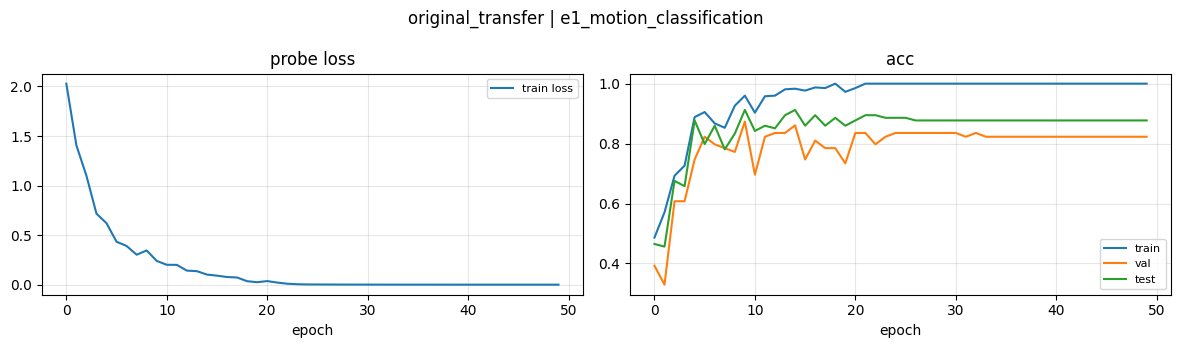

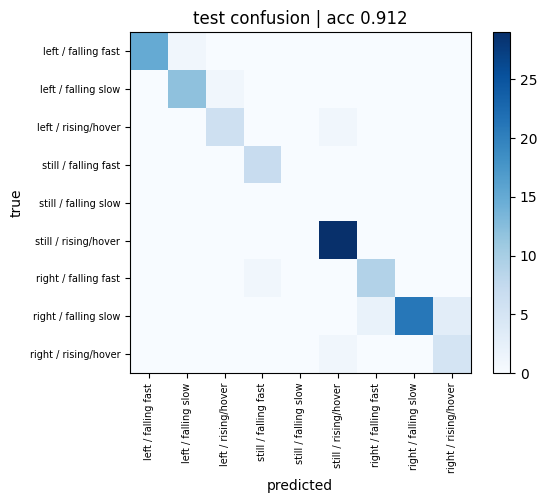

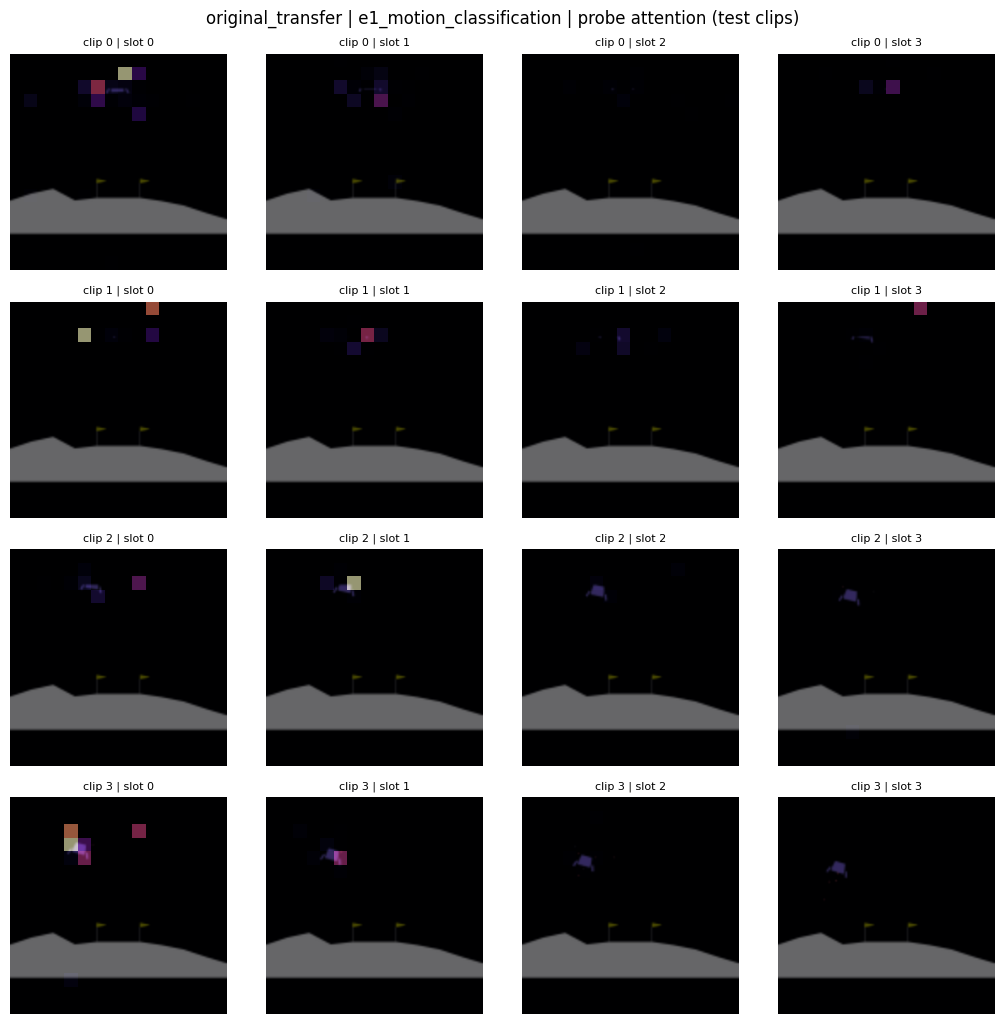

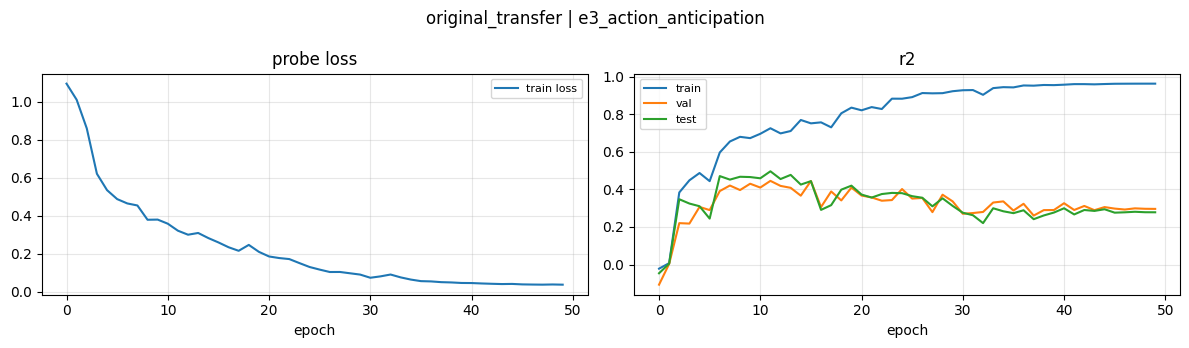

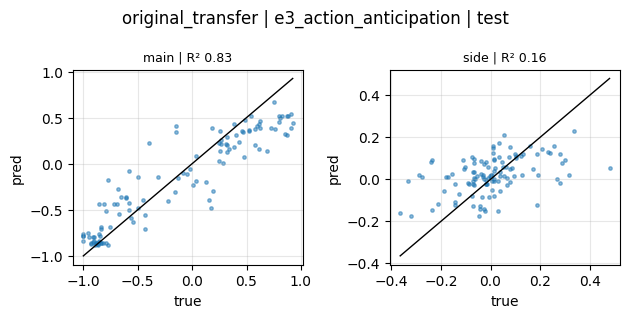

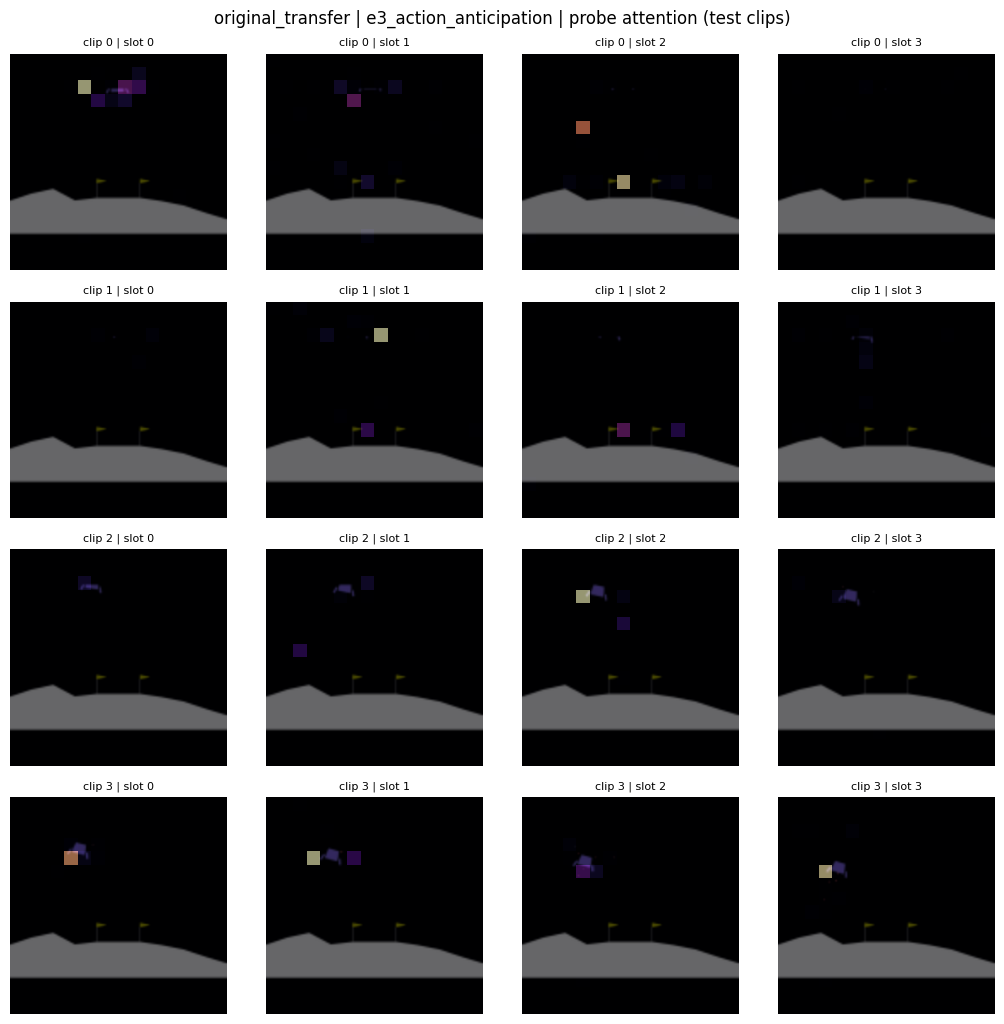

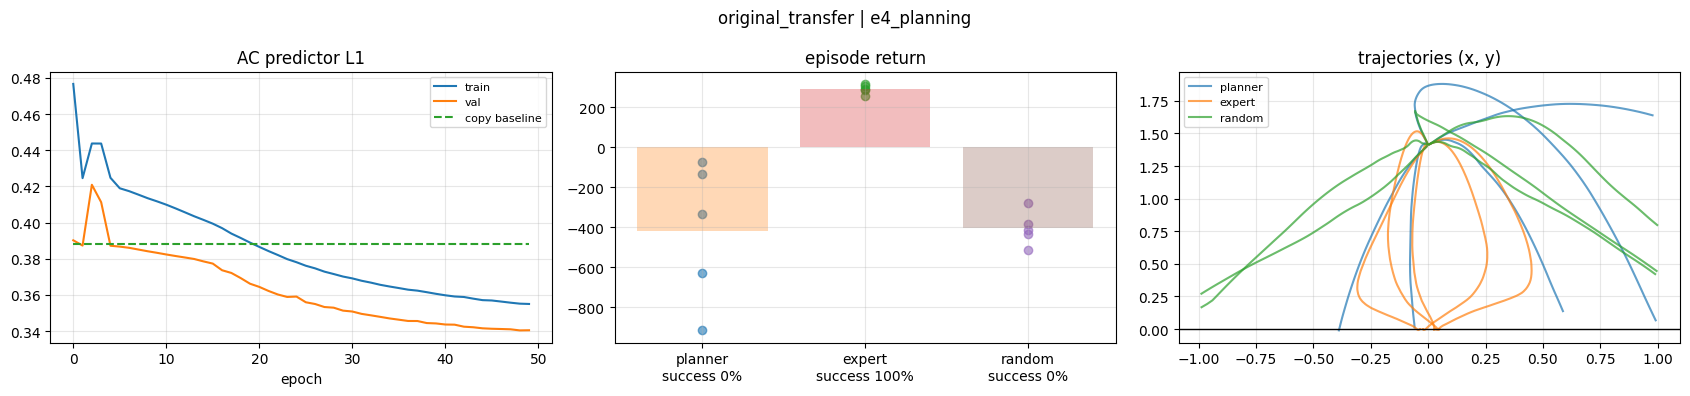

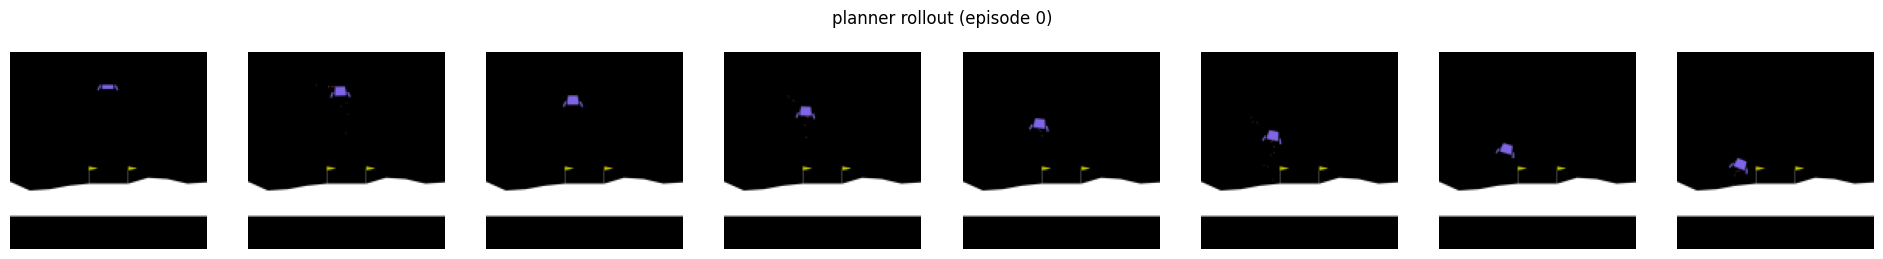

In [41]:
# Comparison - Original JEPA

original_results = run_testing_experiments(original_model)

display(pd.DataFrame({name: result["metrics"] for name, result in original_results.items()}).T)
plot_testing_experiments(original_results)

[18:55:11] [original_transfer] planner loaded from /Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/experiments/original_transfer/planner.pt


/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_17040/2838506509.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, depth)


[18:57:11] [original_transfer] inference episode 1/5 | steps 94 | return -836.4 | landed False | crashed True
[18:59:04] [original_transfer] inference episode 2/5 | steps 90 | return -823.6 | landed False | crashed True
[19:00:28] [original_transfer] inference episode 3/5 | steps 68 | return -136.2 | landed False | crashed True
[19:02:33] [original_transfer] inference episode 4/5 | steps 93 | return -140.2 | landed False | crashed True
[19:05:20] [original_transfer] inference episode 5/5 | steps 130 | return -725.3 | landed False | crashed True
[19:05:20] [original_transfer] inference done | success 0% | mean return -532.3 | /Users/adriankazi/vid_to_pol/Video-to-Policy-Model/notebooks/artifacts/tubelet_motion/experiments/original_transfer/inference/episodes.mp4


,original_transfer
episodes,5.000000
success_rate,0.000000
crash_rate,1.000000
timeout_rate,0.000000
mean_return,-532.347842
mean_steps,95.000000
mean_final_abs_x,0.796885
mean_final_y,0.505164
mean_touchdown_vx,0.643605
mean_touchdown_vy,-1.710130


,episode,return,steps,landed,crashed,timeout,final_abs_x,final_y,touchdown_vx,touchdown_vy,touchdown_abs_angle,mean_abs_angle,max_abs_angle,mean_abs_angular_vel,mean_vy,max_speed,action_jerk,main_engine_usage,side_engine_usage
0,0,-836.401733,94,False,True,False,1.009621,1.589047,1.374084,-1.488611,4.951684,1.651509,4.951684,1.042696,0.077865,2.290361,0.037799,0.836953,0.479855
1,1,-823.635376,90,False,True,False,1.000784,1.061127,1.501540,-1.839179,5.035686,1.865300,5.035686,1.106831,-0.175944,2.484309,0.062141,0.750690,0.473437
2,2,-136.220520,68,False,True,False,0.300379,-0.061811,-0.672785,-1.385869,0.603109,0.274408,0.603109,0.235626,-0.945466,1.540543,0.088117,0.316959,0.035861
3,3,-140.163651,93,False,True,False,0.669419,-0.161537,-0.666987,-1.521662,0.272929,0.096591,0.273927,0.157311,-0.743480,1.690375,0.082534,0.259977,0.105793
4,4,-725.317932,130,False,True,False,1.004222,0.098993,1.682173,-2.315330,3.963412,1.270473,3.963412,0.612581,-0.453783,2.861898,0.088859,0.669347,0.217693


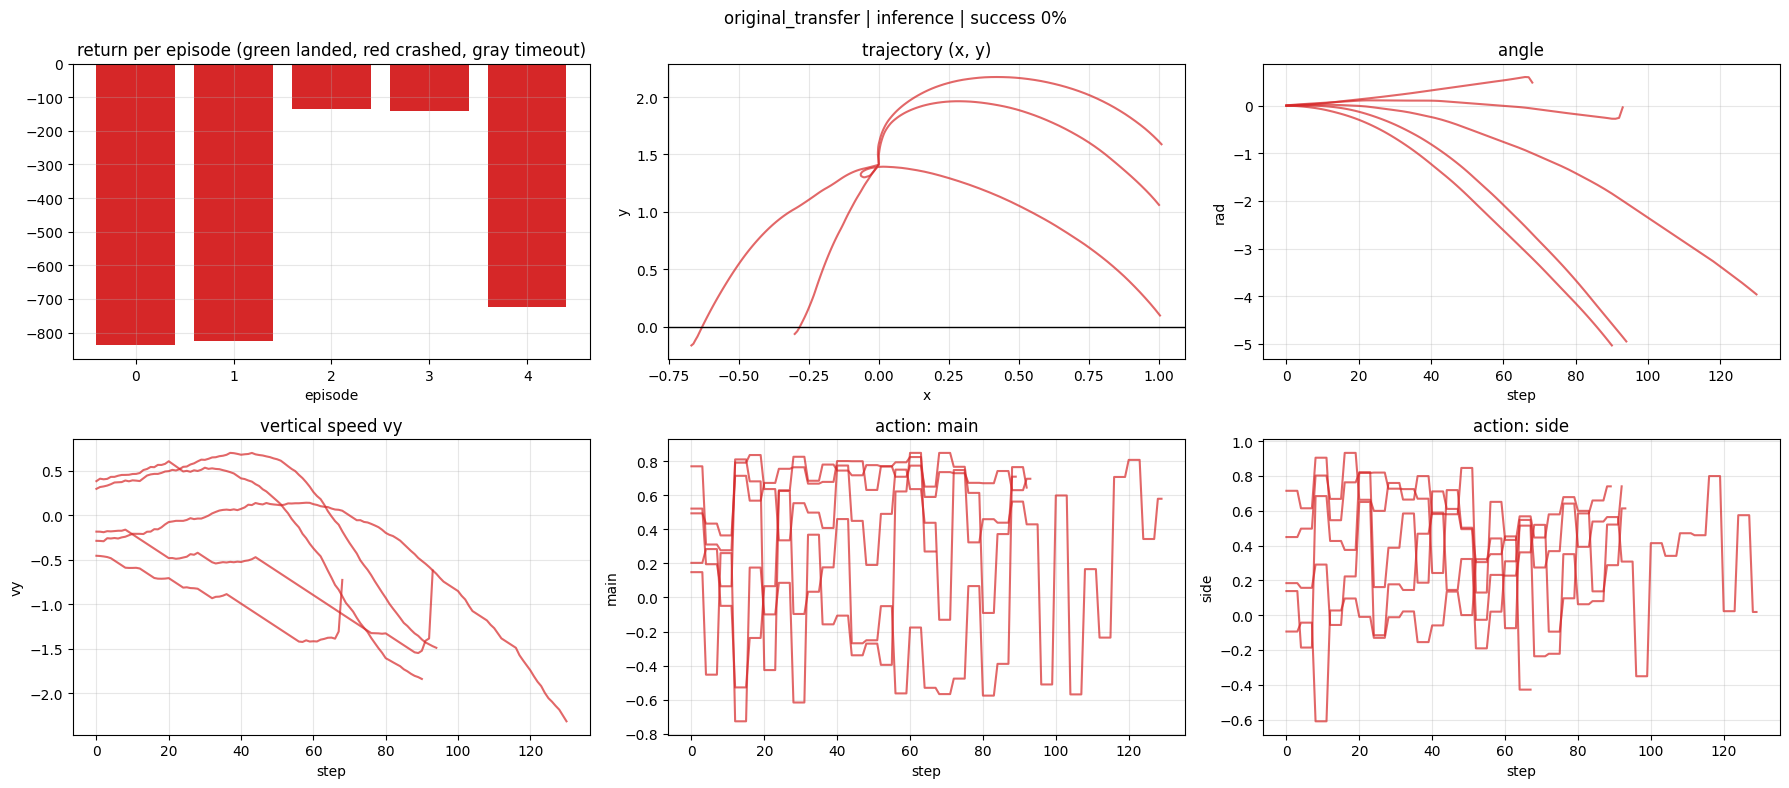

In [42]:
# Comparison - Original JEPA - Inference

original_inference = run_inference(original_model, 5)
plot_inference(original_inference)

## Modified JEPA

In [ ]:
# Comparison - Modified JEPA

modified_results = run_testing_experiments(modified_model)

display(pd.DataFrame({name: result["metrics"] for name, result in modified_results.items()}).T)
plot_testing_experiments(modified_results)

In [ ]:
# Comparison - Modified JEPA - Inference

modified_inference = run_inference(modified_model, 5)
plot_inference(modified_inference)

## Original vs Modified

Same evals, same env seeds. Positive `diff` = modified is higher.

In [ ]:
# Comparison - Original vs Modified

def flat_metrics(results, inference):
    rows = {f"{exp}/{k}": v for exp, r in results.items() for k, v in r["metrics"].items() if isinstance(v, (int, float))}
    rows.update({f"inference/{k}": v for k, v in inference["metrics"].items() if isinstance(v, (int, float))})
    return rows


comparison = pd.DataFrame({
    "original": flat_metrics(original_results, original_inference),
    "modified": flat_metrics(modified_results, modified_inference),
})
comparison["diff"] = comparison["modified"] - comparison["original"]
display(comparison)

headline = [
    "e1_motion_classification/test_acc",
    "e3_action_anticipation/test_r2",
    "e4_planning/ac_test_l1",
    "e4_planning/diag_expert_beats_random_weighted",
    "e4_planning/planner_return",
    "inference/success_rate",
    "inference/mean_return",
]
headline = [k for k in headline if k in comparison.index]

fig, axes = plt.subplots(1, len(headline), figsize=(3 * len(headline), 3.5))
for ax, key in zip(np.atleast_1d(axes), headline):
    ax.bar(["original", "modified"], comparison.loc[key, ["original", "modified"]], color=["tab:gray", "tab:blue"])
    ax.set_title(key.replace("/", "\n"), fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evals

## Frozen Evaluation (Probe)

A JEPA encoder outputs tokens, not labels, so it can't be scored directly. Standard check (V-JEPA 2, SSv2 attentive probe → 77.3% top-1): **freeze the encoder, train only a small head on its tokens, measure accuracy.** High accuracy = the information was already in the representation.

**Something-Something v2 (SSv2):** ~170k crowdsourced clips, 174 motion templates (e.g. *Pushing [something] from left to right* vs *from right to left*). Objects vary, so the label is only recoverable from motion.

**Steps**

1. Pretrain V-JEPA 2 on unlabeled video (not SSv2).
2. Freeze the encoder: no gradient ever reaches it.
3. Encode SSv2 train clips (16 frames) → tokens `[N, 1024]`.
4. Train a probe on the tokens:
   - **linear probe:** mean-pool tokens → `nn.Linear(1024, 174)`
   - **attentive probe:** a few attention layers + a learned query token cross-attending over all tokens → `nn.Linear(1024, 174)` (`VJEPA2AttentivePooler` in `transformers`)
5. Loss: cross-entropy. Only the probe is updated.
6. Encode SSv2 val clips with the same frozen encoder → report top-1 accuracy.

**Frozen eval ≠ fine-tuning:** fine-tuning also updates the encoder with labels and hides what pretraining alone learned.

**For this project:** same protocol on LunarLander — motion classes (E1) and upcoming actions (E3) from frozen tokens, original vs modified encoder.

## Experiment Plan

**Goal:** show that the modified JEPA (motion embeddings) learns a better representation than the original V-JEPA 2.

**Setup — transfer learning: both models start from Meta's V-JEPA 2 ViT-L weights**

1. Two models: **original** V-JEPA 2 and **modified** (motion embeddings). The modification is the *only* difference.
2. Identical everything else: data, model size, steps, batch, lr schedule, masks, seeds.
3. Data: LunarLander only — JEPA fine-tuning on `train` episodes, evals on held-out `probe` episodes and fresh env rollouts.
4. 3+ seeds per model.

**Evaluation (V-JEPA 2 paper evals, frozen encoder)**

- E1 motion classification (top-1), E3 action anticipation (R²), E4 planning with V-JEPA 2-AC (success, return).
- Inference: closed-loop control, reward and landing stability metrics + video.
- During pretraining: loss, norms, effective rank / feature std (collapse check) → storage.

**Result:** a paper if modified > original consistently across seeds (gap larger than seed spread).
